# 🏦 Predicción de la Suscripción de Clientes a Depósitos a Plazo mediante Machine Learning

### Proyecto de Ciencia de Datos para Optimizar Campañas de Marketing Bancario

---

**👤 Autor:** María Isabel Durango

**🎓 Rol:** Estudiante de Ciencia de Datos

**📌 Tipo de proyecto:** Machine Learning Supervisado – Clasificación Binaria

**📂 Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)

**📖 Metodología:** CRISP-DM

🛠 Tecnologías utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

## 📑 Índice

1️⃣ Comprensión del negocio

2️⃣ Comprensión de los datos

3️⃣ Preparación de los datos

4️⃣ Análisis Exploratorio de Datos (EDA)

5️⃣ Ingeniería de Características

6️⃣ Modelado

7️⃣ Evaluación

8️⃣ Conclusiones

9️⃣ Trabajo Futuro

# 1️⃣ Comprensión del Negocio

## 📖 Contexto del negocio

Las instituciones financieras invierten grandes cantidades de recursos en campañas de marketing con el objetivo de promocionar productos financieros, como los depósitos a plazo fijo.

Estas campañas suelen realizarse mediante llamadas telefónicas a potenciales clientes, por lo que es fundamental identificar previamente qué personas tienen mayor probabilidad de aceptar la oferta.

Contar con un modelo predictivo permite optimizar la estrategia comercial, reducir costos operativos y aumentar la efectividad de las campañas de marketing.

---

## 🚨 Problema del negocio

Las campañas de marketing telefónico implican un alto costo económico y de tiempo.

Contactar a todos los clientes disponibles no resulta eficiente, ya que la mayoría no aceptará la oferta.

La entidad financiera necesita una herramienta que permita identificar, antes de realizar la llamada, qué clientes presentan una mayor probabilidad de suscribirse a un depósito a plazo.

---

## 🎯 Objetivo del negocio

Desarrollar un modelo de Machine Learning capaz de predecir si un cliente aceptará o no un depósito a plazo, permitiendo priorizar aquellos clientes con mayor probabilidad de conversión y optimizar la inversión en campañas de marketing.

---

## 🤖 Objetivo del modelo 

Construir, entrenar y comparar diferentes algoritmos de clasificación para seleccionar el modelo con mejor desempeño predictivo, manteniendo un equilibrio entre precisión, capacidad de generalización e interpretabilidad.

---



## 🔄 Metodología CRISP-DM

Este proyecto sigue la metodología CRISP-DM, uno de los estándares más utilizados en proyectos de Ciencia de Datos.

El proyecto se desarrollará siguiendo las siguientes fases:

📌 Comprensión del negocio

📊 Comprensión de los datos

🧹 Preparación de los datos

📈 Análisis Exploratorio de Datos (EDA)

⚙️ Ingeniería de Características

🤖 Modelado

📉 Evaluación

🚀 Conclusiones y recomendaciones

In [13]:
# =============================================================================
# Standard library imports
# =============================================================================
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings

# =============================================================================
# Data manipulation
# =============================================================================
import pandas as pd
import numpy as np

# =============================================================================
# Visualization
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# =============================================================================
# Display configuration
# =============================================================================
pd.set_option('display.max_columns', None)   # Show all columns in outputs
pd.set_option('display.max_rows', 100)       # Show up to 100 rows
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places

# =============================================================================
# Visual style — single consistent theme for the entire notebook
# =============================================================================
PALETTE = ['#2C5F8A', '#E8734A', '#4CAF7D', '#9B59B6', '#F39C12']
sns.set_theme(
    style='whitegrid',          # Clean grid, professional look
    palette=PALETTE,            # Custom color palette (consistent throughout)
    font='DejaVu Sans',         # Standard readable font
    font_scale=1.1              # Slightly larger text for readability
)
plt.rcParams['figure.figsize'] = (12, 6)    # Default figure size
plt.rcParams['figure.dpi'] = 100            # Resolution
plt.rcParams['axes.titlesize'] = 14         # Title font size
plt.rcParams['axes.labelsize'] = 12         # Axis label font size

print("✅ Libraries imported and configuration applied successfully")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")
print(f"   matplotlib: {plt.matplotlib.__version__}")

✅ Libraries imported and configuration applied successfully
   pandas  : 3.0.3
   numpy   : 2.5.0
   seaborn : 0.13.2
   matplotlib: 3.11.0


In [3]:
# Ruta del dataset
data_path = "../data/raw/bank-additional-full.csv"

# Cargar datos
df = pd.read_csv(data_path, sep=";")

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [5]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### ⚠️ Nota importante: Variable `duration`

La variable `duration` mide la duración en segundos de la última llamada telefónica con el cliente.

Aunque tiene alta correlación con el target `y`, **será excluida del modelo predictivo** por la siguiente razón:

> En el momento real de uso del modelo —es decir, cuando el agente decide **a quién llamar**—, 
> la llamada todavía no ha ocurrido. Por tanto, la duración de esa llamada es desconocida.

Incluir `duration` en el modelo sería una forma de **data leakage**: 
estaríamos usando información del futuro para predecir el presente, 
lo que haría que el modelo parezca mejor de lo que realmente es en producción.

**Referencia**: Los propios autores del dataset (Moro et al., 2014) reconocen esta limitación 
explícitamente en su paper original.

`duration` se mantiene en el dataset durante el EDA para análisis exploratorio, 
pero será **eliminada antes del entrenamiento de cualquier modelo**.

In [6]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 41188
Columnas: 21


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [14]:
# Descriptive statistics for numeric variables
print("=== Numeric Variables ===")
display(df.describe(include=[np.number]).T)  # .T transposes for easier reading

print("\n=== Categorical Variables ===")
# Use select_dtypes to avoid Pandas 2.x deprecation warning
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[categorical_cols].describe())

=== Numeric Variables ===


,count,mean,std,min,25%,50%,75%,max
age,41188.0000,40.0241,10.4212,17.0000,32.0000,38.0000,47.0000,98.0000
duration,41188.0000,258.2850,259.2792,0.0000,102.0000,180.0000,319.0000,4918.0000
campaign,41188.0000,2.5676,2.7700,1.0000,1.0000,2.0000,3.0000,56.0000
pdays,41188.0000,962.4755,186.9109,0.0000,999.0000,999.0000,999.0000,999.0000
previous,41188.0000,0.1730,0.4949,0.0000,0.0000,0.0000,0.0000,7.0000
emp.var.rate,41188.0000,0.0819,1.5710,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons.price.idx,41188.0000,93.5757,0.5788,92.2010,93.0750,93.7490,93.9940,94.7670
cons.conf.idx,41188.0000,-40.5026,4.6282,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000
euribor3m,41188.0000,3.6213,1.7344,0.6340,1.3440,4.8570,4.9610,5.0450
nr.employed,41188.0000,5167.0359,72.2515,4963.6000,5099.1000,5191.0000,5228.1000,5228.1000



=== Categorical Variables ===


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [17]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [18]:
# =============================================================================
# Analysis of 'unknown' values
# IMPORTANT: In this dataset, missing values are encoded as the string "unknown"
# They do NOT appear as NaN, so isnull() does not detect them.
# We must identify and quantify them explicitly.
# =============================================================================

print("=== 'unknown' values per column ===\n")

unknown_counts = {}
for col in df.select_dtypes(exclude=[np.number]).columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        pct = count / len(df) * 100
        unknown_counts[col] = {'count': count, 'percentage': pct}
        print(f"  {col:<15} → {count:>5} unknowns ({pct:.2f}%)")

if not unknown_counts:
    print("  No 'unknown' values found in categorical columns.")

print(f"\nTotal rows: {len(df):,}")
print("\n⚠️  NOTE: These are NOT NaN values — they are explicit 'unknown' strings.")
print("    Strategy: Treat 'unknown' as a separate valid category.")
print("    Reason: The fact that a value is unknown IS information in itself.")
print("    We will NOT drop these rows — this decision will be justified in the cleaning phase.")

=== 'unknown' values per column ===

  job             →   330 unknowns (0.80%)
  marital         →    80 unknowns (0.19%)
  education       →  1731 unknowns (4.20%)
  default         →  8597 unknowns (20.87%)
  housing         →   990 unknowns (2.40%)
  loan            →   990 unknowns (2.40%)

Total rows: 41,188

⚠️  NOTE: These are NOT NaN values — they are explicit 'unknown' strings.
    Strategy: Treat 'unknown' as a separate valid category.
    Reason: The fact that a value is unknown IS information in itself.
    We will NOT drop these rows — this decision will be justified in the cleaning phase.


In [21]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

## 2. Comprensión de los Datos

### 2.1 Análisis Exploratorio Univariante

El análisis univariante estudia cada variable de forma **independiente** para comprender 
su distribución, detectar valores atípicos e identificar patrones que guiarán las 
decisiones de limpieza y preprocesamiento.

**Orden de análisis:**
1. 🎯 Variable objetivo (`y`) — punto de partida obligatorio en cualquier proyecto supervisado
2. 🔢 Variables numéricas — distribución, sesgo y outliers  
3. 🔤 Variables categóricas — frecuencias, cardinalidad y valores `unknown`

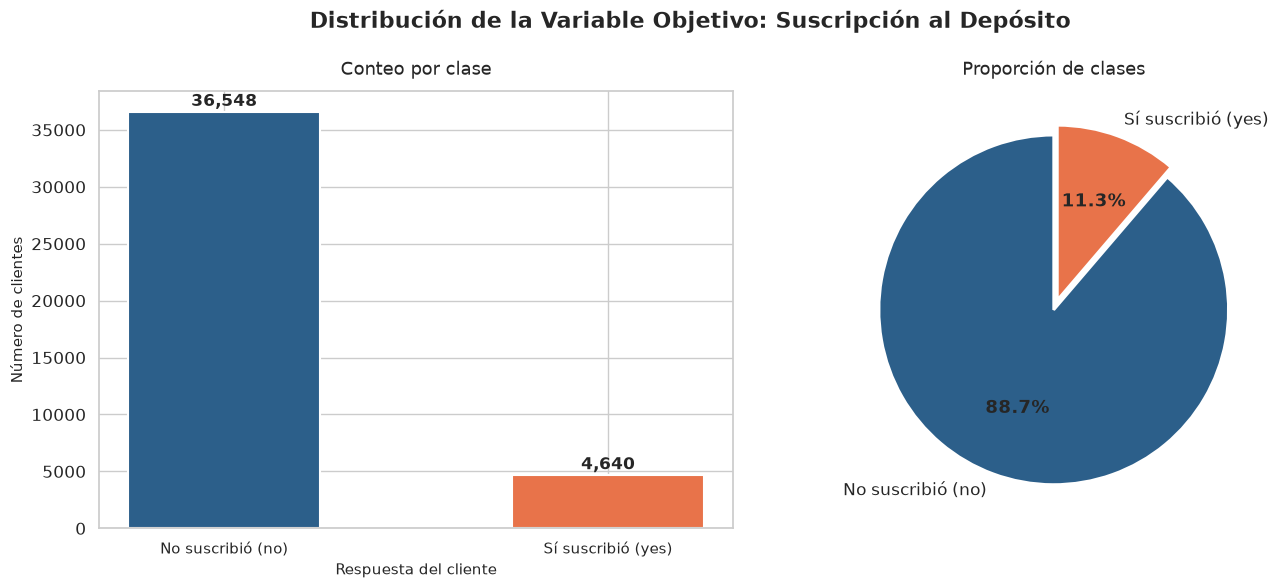

   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
    no  ████████████████████████████████████████████  36,548 (88.7%)
   yes  █████                                          4,640 (11.3%)
-------------------------------------------------------
  Ratio de desbalanceo : 1 : 7.9
  Total clientes       : 41,188


In [22]:
# =============================================================================
# EDA 1/3 — TARGET VARIABLE ANALYSIS
# =============================================================================

def plot_target_distribution(df: pd.DataFrame, 
                             target_col: str = 'y') -> None:
    """
    Plot target variable distribution showing class imbalance.
    
    Args:
        df: Input DataFrame containing the target column
        target_col: Name of the binary target column (default: 'y')
    
    Returns:
        None — saves figure to reports/figures/
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Distribución de la Variable Objetivo: Suscripción al Depósito', 
                 fontsize=16, fontweight='bold')
    
    value_counts = df[target_col].value_counts()
    colors = [PALETTE[0], PALETTE[1]]
    
    # --- Bar chart: absolute counts ---
    bars = axes[0].bar(
        value_counts.index, 
        value_counts.values,
        color=colors, 
        edgecolor='white', 
        linewidth=1.5,
        width=0.5
    )
    axes[0].set_title('Conteo por clase', fontsize=13, pad=12)
    axes[0].set_xlabel('Respuesta del cliente', fontsize=11)
    axes[0].set_ylabel('Número de clientes', fontsize=11)
    axes[0].set_xticks(range(len(value_counts)))
    axes[0].set_xticklabels(['No suscribió (no)', 'Sí suscribió (yes)'], fontsize=11)
    
    for bar, count in zip(bars, value_counts.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, 
            bar.get_height() + 200,
            f'{count:,}', 
            ha='center', va='bottom',
            fontsize=12, fontweight='bold'
        )
    
    # --- Pie chart: proportions ---
    pct = df[target_col].value_counts(normalize=True) * 100
    wedges, texts, autotexts = axes[1].pie(
        pct.values,
        labels=['No suscribió (no)', 'Sí suscribió (yes)'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=(0, 0.06),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')
    axes[1].set_title('Proporción de clases', fontsize=13, pad=12)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/01_target_distribution.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Summary statistics ---
    print("=" * 55)
    print("   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
    print("=" * 55)
    for label, count in value_counts.items():
        pct_val = count / len(df) * 100
        bar_vis = '█' * int(pct_val / 2)
        print(f"  {label:>4}  {bar_vis:<45} {count:>6,} ({pct_val:.1f}%)")
    print("-" * 55)
    print(f"  Ratio de desbalanceo : 1 : {value_counts['no'] / value_counts['yes']:.1f}")
    print(f"  Total clientes       : {len(df):,}")
    print("=" * 55)


plot_target_distribution(df)

#### 🔍 Interpretación: Variable Objetivo `y`

| Clase | Clientes | Porcentaje |
|---|---|---|
| **no** — no suscribió | ~36.548 | ~88,7% |
| **yes** — sí suscribió | ~4.640 | ~11,3% |

**Hallazgo clave — Desbalanceo de clases (8:1)**

El dataset presenta un desbalanceo significativo: por cada cliente que suscribe 
el depósito, hay aproximadamente **8 que no lo hacen**.

**Implicación técnica directa:**
Un modelo que prediga siempre `"no"` obtendría un *accuracy* del **88,7%** 
sin haber aprendido absolutamente nada. Por esta razón, el *accuracy* 
queda **descartado como métrica principal** desde este momento.

**Métricas que usaremos:**
- **Recall** de la clase `yes` → cuántos clientes interesados identificamos
- **Precision** de la clase `yes` → de los que identificamos, cuántos realmente suscriben  
- **F1-score** → equilibrio entre ambas
- **ROC-AUC** → capacidad discriminatoria global del modelo

**Impacto de negocio:**
Cada cliente `yes` no identificado es una oportunidad de negocio perdida para el banco. 
El modelo debe ser especialmente sensible a detectar la clase minoritaria.

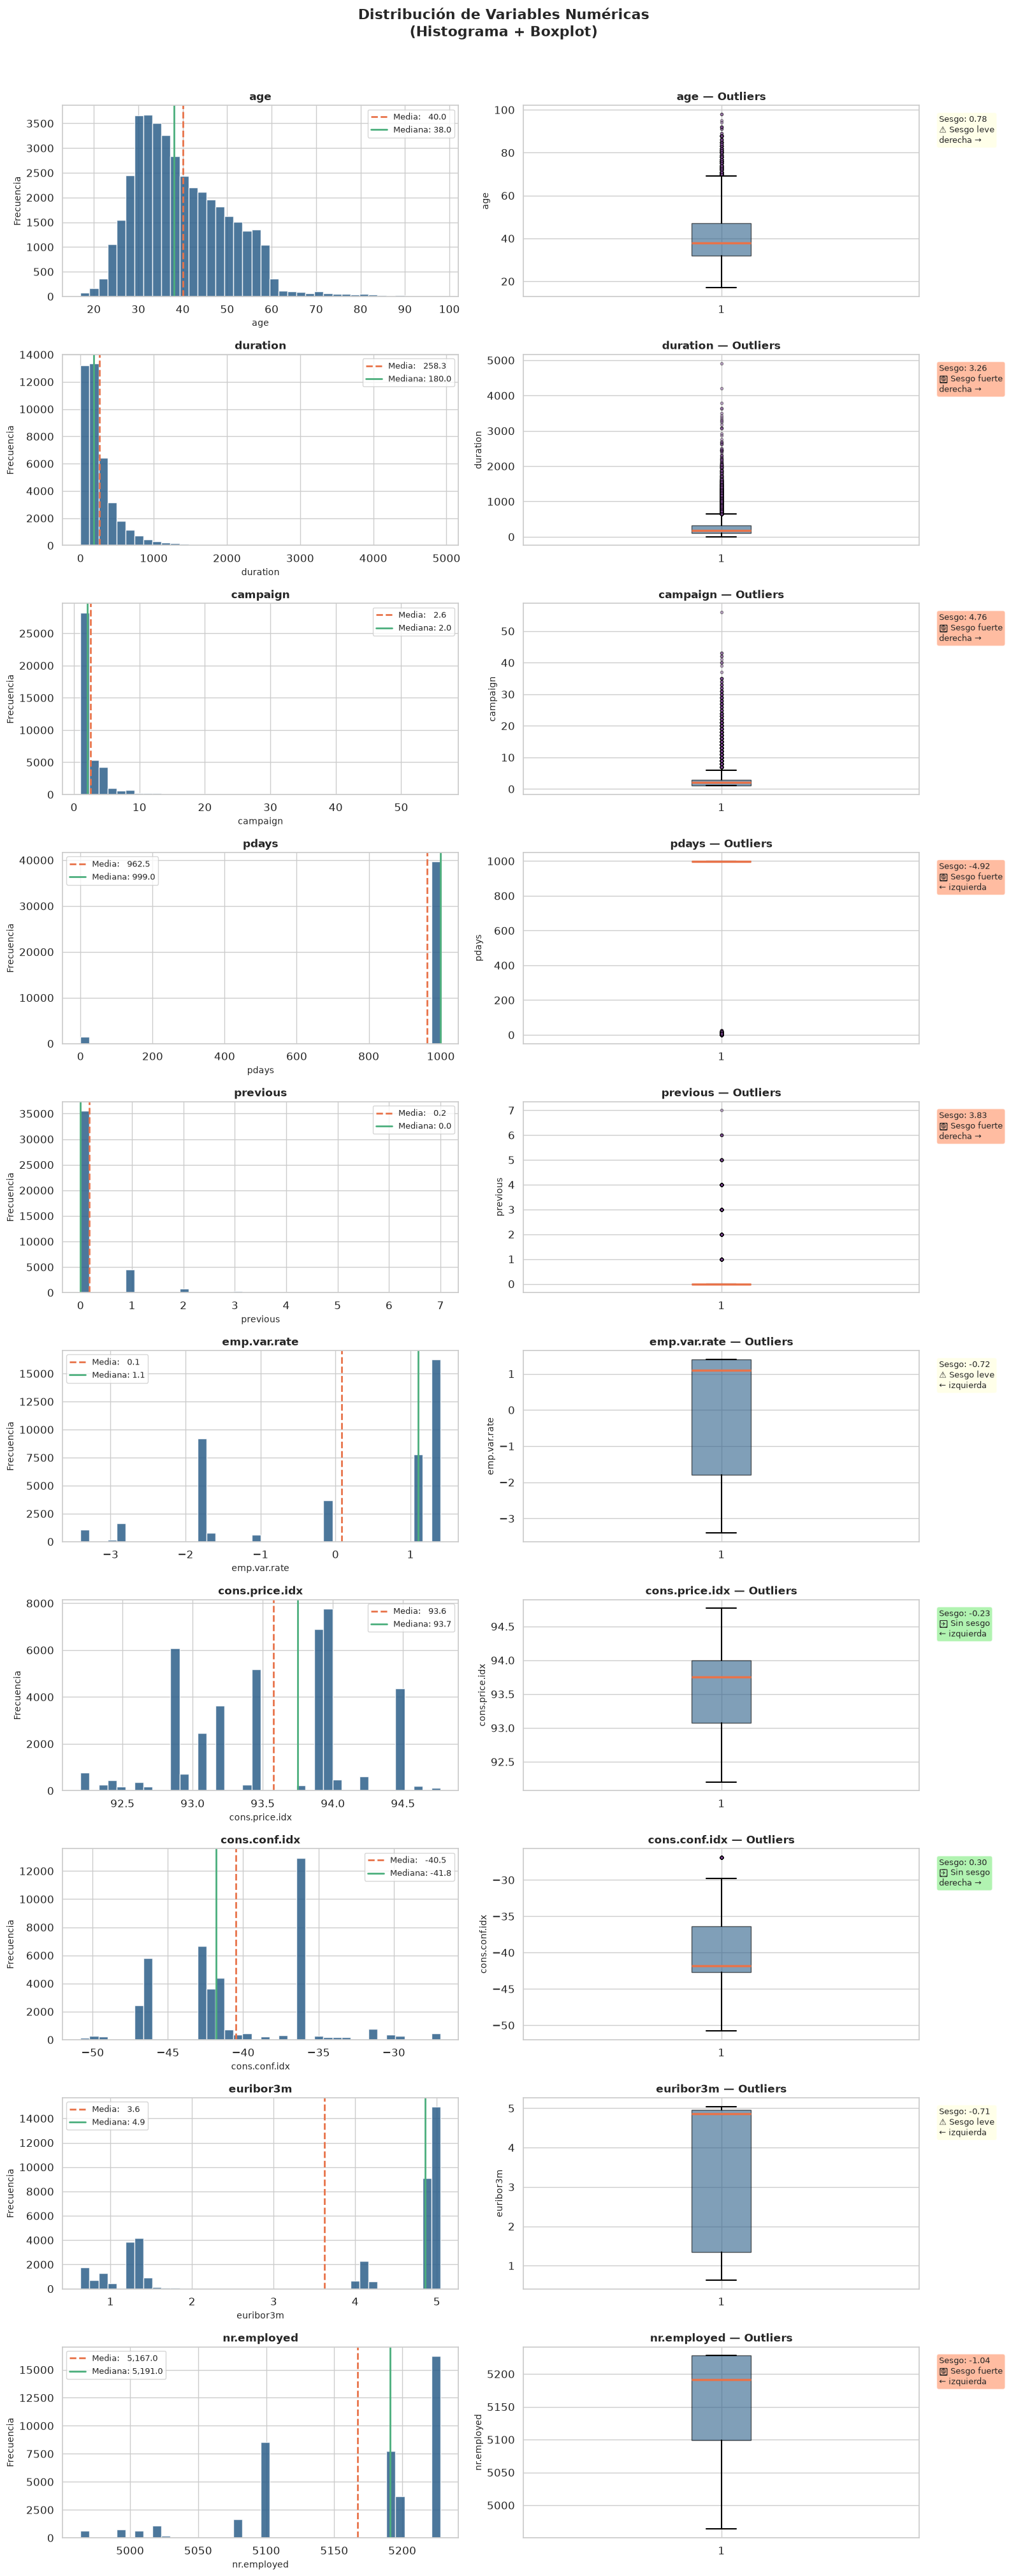


=== RESUMEN ESTADÍSTICO — Variables Numéricas ===



,mean,std,min,25%,50%,75%,max,sesgo,riesgo_outlier
age,40.0200,10.4200,17.0000,32.0000,38.0000,47.0000,98.0000,0.7850,🟡 Medio
duration,258.2900,259.2800,0.0000,102.0000,180.0000,319.0000,4918.0000,3.2630,🔴 Alto
campaign,2.5700,2.7700,1.0000,1.0000,2.0000,3.0000,56.0000,4.7630,🔴 Alto
pdays,962.4800,186.9100,0.0000,999.0000,999.0000,999.0000,999.0000,-4.9220,🔴 Alto
previous,0.1700,0.4900,0.0000,0.0000,0.0000,0.0000,7.0000,3.8320,🔴 Alto
emp.var.rate,0.0800,1.5700,-3.4000,-1.8000,1.1000,1.4000,1.4000,-0.7240,🟡 Medio
cons.price.idx,93.5800,0.5800,92.2000,93.0800,93.7500,93.9900,94.7700,-0.2310,🟢 Bajo
cons.conf.idx,-40.5000,4.6300,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000,0.3030,🟢 Bajo
euribor3m,3.6200,1.7300,0.6300,1.3400,4.8600,4.9600,5.0400,-0.7090,🟡 Medio
nr.employed,5167.0400,72.2500,4963.6000,5099.1000,5191.0000,5228.1000,5228.1000,-1.0440,🔴 Alto


In [23]:
# =============================================================================
# EDA 2/3 — NUMERICAL VARIABLES ANALYSIS
# =============================================================================

def plot_numerical_distributions(df: pd.DataFrame,
                                  exclude_cols: list = None) -> pd.DataFrame:
    """
    Plot histogram + boxplot for each numerical variable.
    Annotates mean, median and skewness on each plot.
    
    Args:
        df: Input DataFrame
        exclude_cols: List of column names to exclude from analysis
    
    Returns:
        DataFrame with summary statistics including skewness and outlier risk
    """
    if exclude_cols is None:
        exclude_cols = []
    
    num_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in exclude_cols]
    
    fig, axes = plt.subplots(len(num_cols), 2, figsize=(16, len(num_cols) * 4))
    fig.suptitle('Distribución de Variables Numéricas\n(Histograma + Boxplot)', 
                 fontsize=16, fontweight='bold', y=1.01)
    
    for i, col in enumerate(num_cols):
        data = df[col].dropna()
        mean_val   = data.mean()
        median_val = data.median()
        skew_val   = data.skew()
        
        # --- Histogram ---
        axes[i, 0].hist(data, bins=40, color=PALETTE[0], 
                        edgecolor='white', alpha=0.85)
        axes[i, 0].axvline(mean_val,   color=PALETTE[1], linestyle='--', 
                           linewidth=2, label=f'Media:   {mean_val:,.1f}')
        axes[i, 0].axvline(median_val, color=PALETTE[2], linestyle='-',  
                           linewidth=2, label=f'Mediana: {median_val:,.1f}')
        axes[i, 0].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel(col, fontsize=10)
        axes[i, 0].set_ylabel('Frecuencia', fontsize=10)
        axes[i, 0].legend(fontsize=9)
        
        # --- Boxplot ---
        axes[i, 1].boxplot(
            data,
            patch_artist=True,
            boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
            medianprops=dict(color=PALETTE[1], linewidth=2.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor=PALETTE[3], 
                           markersize=3, alpha=0.4)
        )
        axes[i, 1].set_title(f'{col} — Outliers', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel(col, fontsize=10)
        
        # Skewness label
        if abs(skew_val) < 0.5:
            skew_label = '✅ Sin sesgo'
            skew_color = 'lightgreen'
        elif abs(skew_val) < 1:
            skew_label = '⚠️ Sesgo leve'
            skew_color = 'lightyellow'
        else:
            skew_label = '🔴 Sesgo fuerte'
            skew_color = 'lightsalmon'
        
        direction = 'derecha →' if skew_val > 0 else '← izquierda'
        axes[i, 1].text(
            1.05, 0.95, 
            f'Sesgo: {skew_val:.2f}\n{skew_label}\n{direction}',
            transform=axes[i, 1].transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=skew_color, alpha=0.7)
        )
    
    plt.tight_layout()
    plt.savefig('../reports/figures/02_numerical_distributions.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Summary table ---
    summary = df[num_cols].describe().T.round(2)
    summary['sesgo']         = df[num_cols].skew().round(3)
    summary['riesgo_outlier'] = summary['sesgo'].abs().apply(
        lambda x: '🔴 Alto' if x > 1 else ('🟡 Medio' if x > 0.5 else '🟢 Bajo')
    )
    return summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 
                    'sesgo', 'riesgo_outlier']]


num_summary = plot_numerical_distributions(df, exclude_cols=['y'])
print("\n=== RESUMEN ESTADÍSTICO — Variables Numéricas ===\n")
display(num_summary)

#### 🔍 Interpretación: Variables Numéricas

**Variables con sesgo fuerte (🔴) — requieren atención en la limpieza:**

| Variable | Observación | Acción en fase de limpieza |
|---|---|---|
| `campaign` | Cola derecha fuerte — hay clientes contactados 50+ veces | Analizar outliers, posible cappingˢ |
| `pdays` | El valor **999** no es un número real de días — significa "sin contacto previo" | Crear variable binaria `was_contacted` |
| `previous` | Sesgada — mayoría contactados 0 veces en campañas anteriores | Tratar junto con `pdays` |
| `cons.price.idx` | Poca variación — indicador macroeconómico relativamente estable en el período | Mantener, útil como contexto económico |

**Variables sin sesgo (🟢) — comportamiento normal:**
- `age`: distribución aproximadamente normal — sin tratamiento especial
- `emp.var.rate`, `euribor3m`, `nr.employed`: indicadores macro con variación controlada

**Nota sobre `pdays`**: ⚠️ El valor 999 es un **código especial** que indica que 
el cliente **no fue contactado** en ninguna campaña anterior.  
No debe tratarse como un número de días — se abordará específicamente en Feature Engineering.

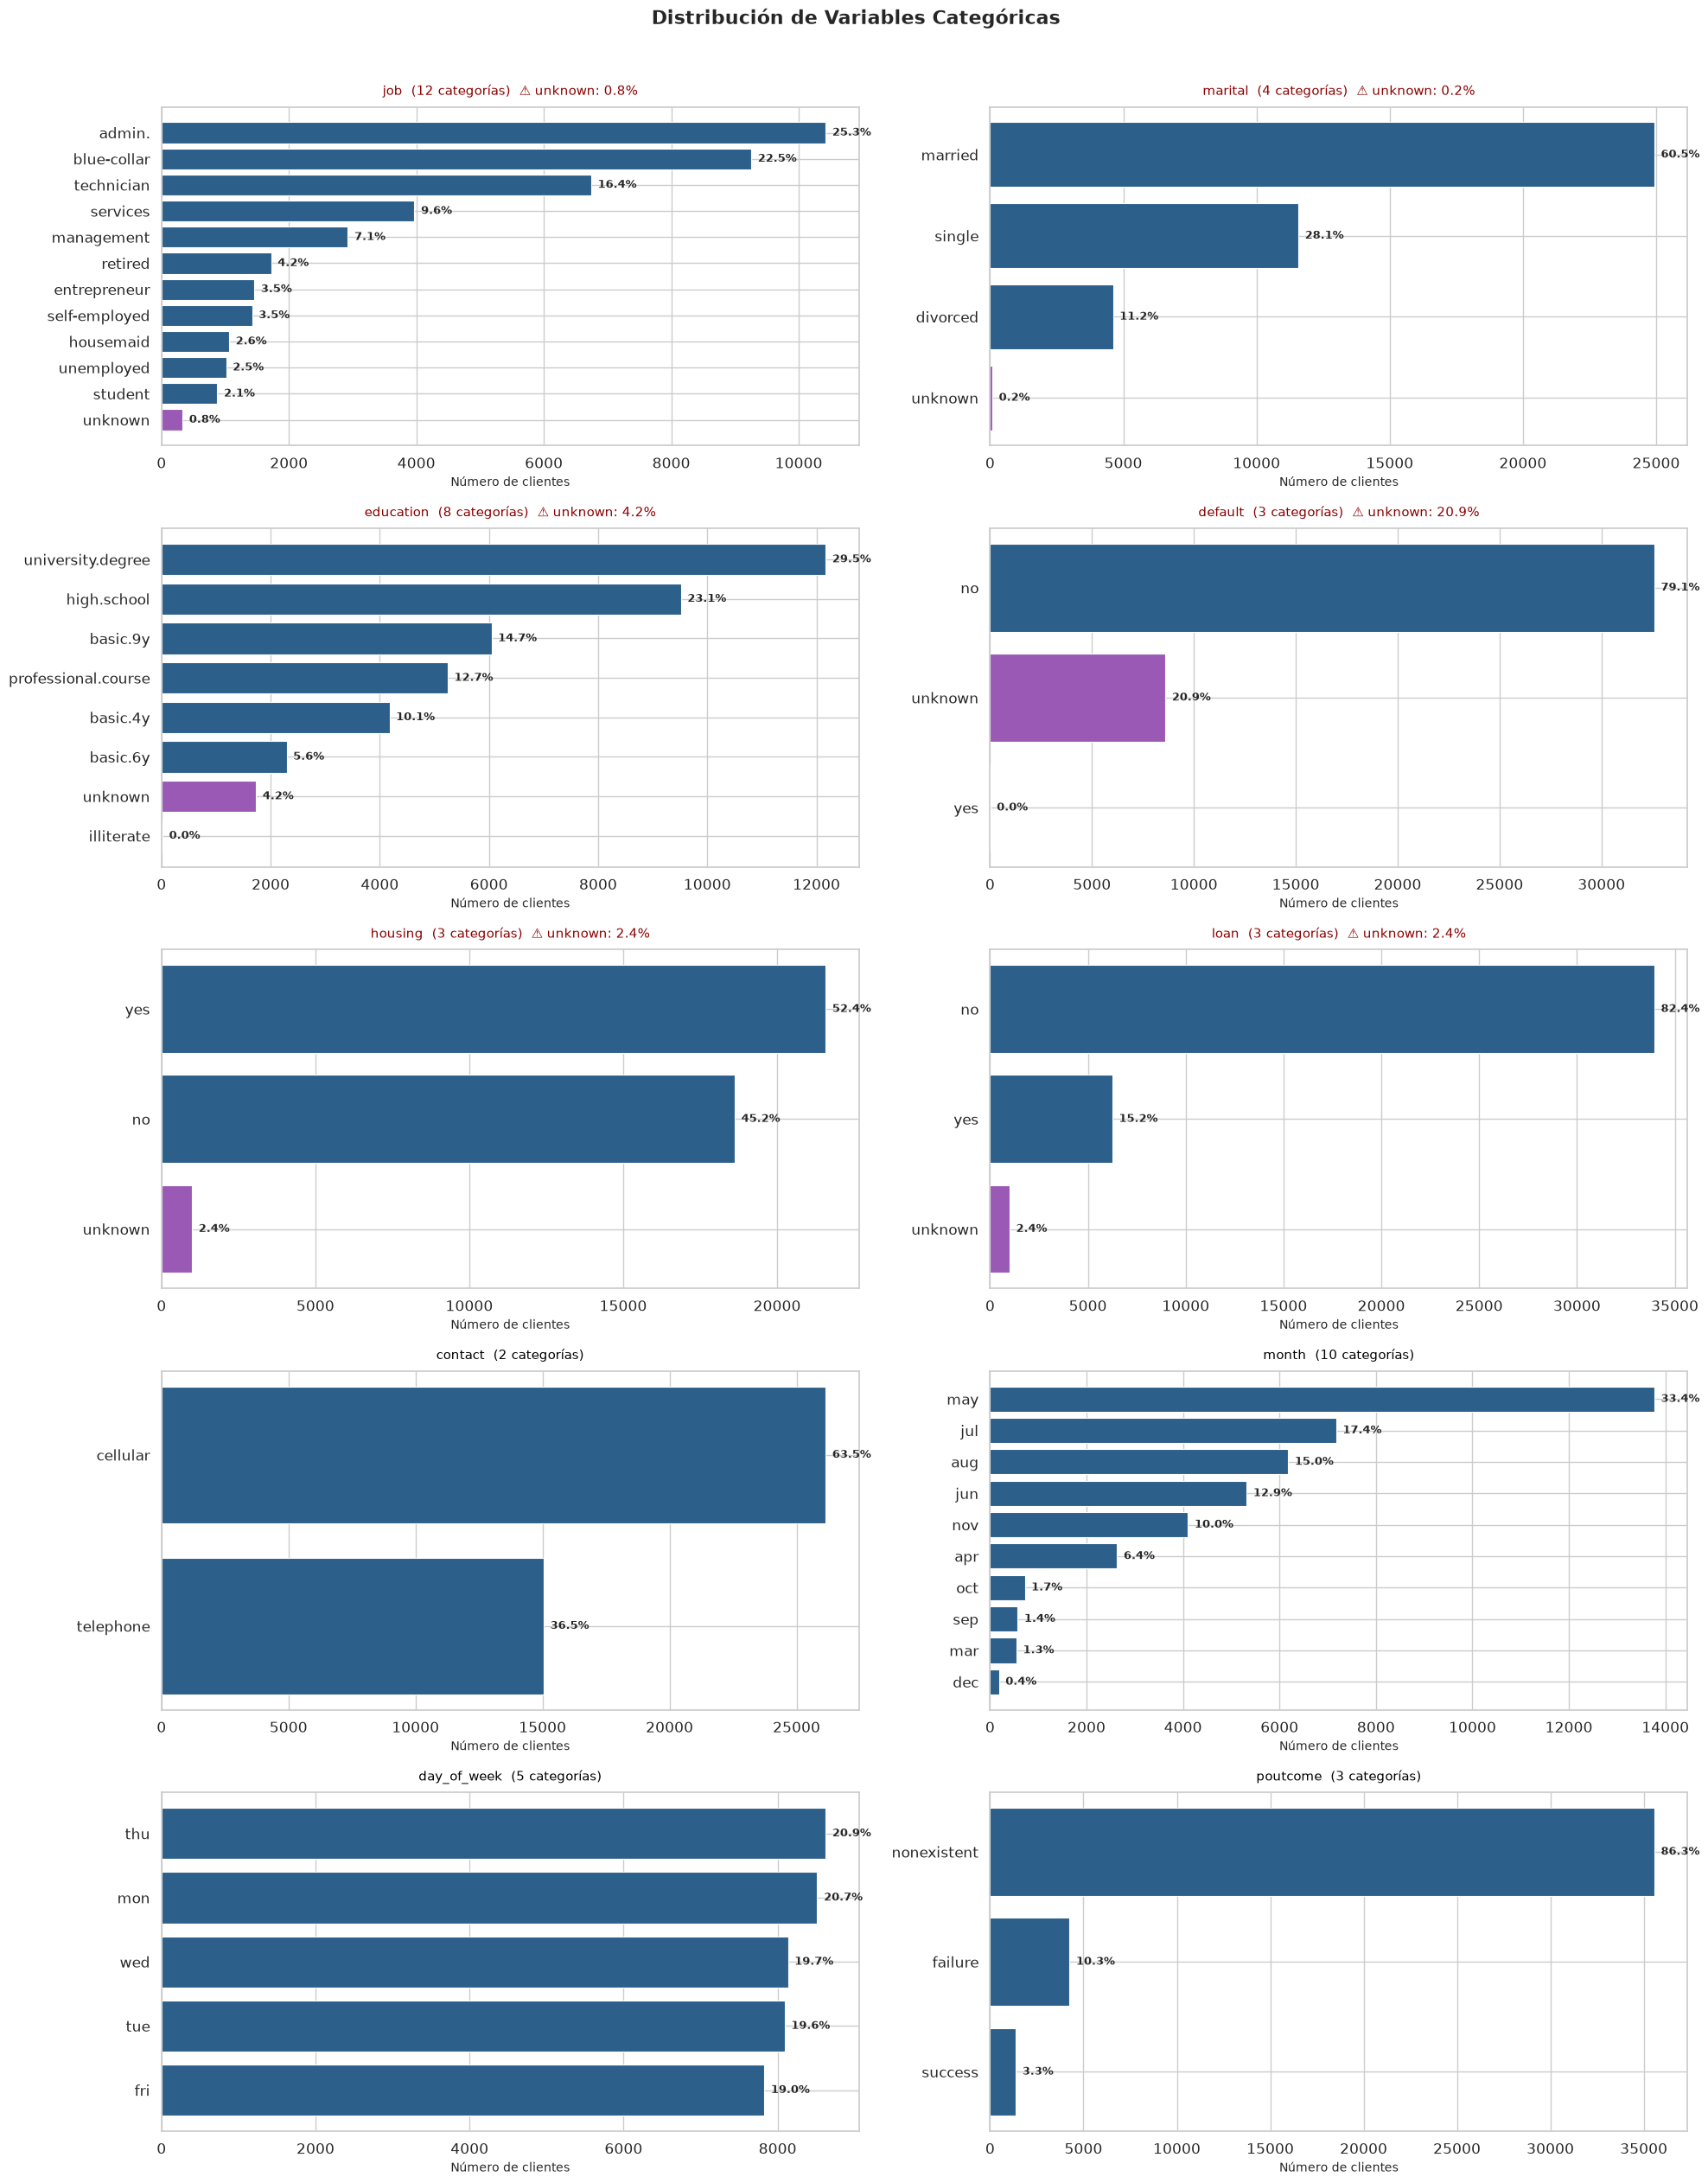


=== RESUMEN — Variables Categóricas ===

Variable              Categorías         Más frecuente    % moda   unknown %
──────────────────────────────────────────────────────────────────────────────
job                           12                admin.     25.3%    ⚠️  0.8%
marital                        4               married     60.5%    ⚠️  0.2%
education                      8     university.degree     29.5%    ⚠️  4.2%
default                        3                    no     79.1%   ⚠️  20.9%
housing                        3                   yes     52.4%    ⚠️  2.4%
loan                           3                    no     82.4%    ⚠️  2.4%
contact                        2              cellular     63.5%           —
month                         10                   may     33.4%           —
day_of_week                    5                   thu     20.9%           —
poutcome                       3           nonexistent     86.3%           —


In [24]:
# =============================================================================
# EDA 3/3 — CATEGORICAL VARIABLES ANALYSIS
# =============================================================================

def plot_categorical_distributions(df: pd.DataFrame,
                                    exclude_cols: list = None) -> None:
    """
    Plot horizontal frequency bar charts for all categorical variables.
    Highlights 'unknown' values in a distinct color for immediate visual detection.
    
    Args:
        df: Input DataFrame
        exclude_cols: Columns to exclude (typically the target variable)
    
    Returns:
        None — saves figure to reports/figures/
    """
    if exclude_cols is None:
        exclude_cols = []
    
    cat_cols = [col for col in df.select_dtypes(exclude=[np.number]).columns
                if col not in exclude_cols]
    
    n_cols = 2
    n_rows = (len(cat_cols) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
    fig.suptitle('Distribución de Variables Categóricas', 
                 fontsize=16, fontweight='bold', y=1.01)
    axes_flat = axes.flatten()
    
    for i, col in enumerate(cat_cols):
        value_counts = df[col].value_counts()
        pct          = df[col].value_counts(normalize=True) * 100
        has_unknown  = 'unknown' in value_counts.index
        
        # Color: unknown in distinct color, rest in palette
        bar_colors = [PALETTE[3] if v == 'unknown' else PALETTE[0] 
                      for v in value_counts.index]
        
        bars = axes_flat[i].barh(
            value_counts.index, 
            value_counts.values,
            color=bar_colors, 
            edgecolor='white', 
            linewidth=0.8
        )
        
        # Percentage labels
        for bar, p in zip(bars, pct.values):
            axes_flat[i].text(
                bar.get_width() + max(value_counts) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{p:.1f}%', va='center', fontsize=9, fontweight='bold'
            )
        
        # Title — warn if has unknown
        title = f'{col}  ({df[col].nunique()} categorías)'
        title_color = '#8B0000' if has_unknown else 'black'
        if has_unknown:
            unknown_pct = (df[col] == 'unknown').sum() / len(df) * 100
            title += f'  ⚠️ unknown: {unknown_pct:.1f}%'
        
        axes_flat[i].set_title(title, fontsize=11, color=title_color, pad=10)
        axes_flat[i].set_xlabel('Número de clientes', fontsize=10)
        axes_flat[i].invert_yaxis()
    
    # Hide unused subplots
    for j in range(len(cat_cols), len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/03_categorical_distributions.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Cardinality and unknown summary ---
    print("\n=== RESUMEN — Variables Categóricas ===\n")
    print(f"{'Variable':<20}{'Categorías':>12}{'Más frecuente':>22}"
          f"{'% moda':>10}{'unknown %':>12}")
    print("─" * 78)
    for col in cat_cols:
        top_val     = df[col].mode()[0]
        top_pct     = (df[col] == top_val).sum() / len(df) * 100
        unknown_pct = (df[col] == 'unknown').sum() / len(df) * 100
        unk_str     = f'⚠️  {unknown_pct:.1f}%' if unknown_pct > 0 else '—'
        print(f"{col:<20}{df[col].nunique():>12}{str(top_val):>22}"
              f"{top_pct:>9.1f}%{unk_str:>12}")


plot_categorical_distributions(df, exclude_cols=['y'])

#### 🔍 Interpretación: Variables Categóricas

**Hallazgos principales:**

| Variable | Hallazgo | Implicación |
|---|---|---|
| `job` | "admin." es la categoría dominante (~25%) | Alta variedad — mantener todas las categorías |
| `marital` | "married" representa ~60% | Distribución razonable, sin categorías raras |
| `education` | "university.degree" y "high.school" dominan | Posible agrupación de niveles bajos |
| `default` | ⚠️ **20,9% unknown** — la variable más problemática | Tratamiento especial obligatorio |
| `contact` | "cellular" domina (~63%) — teléfono fijo es minoría | Variable relevante para el modelo |
| `month` | "may" concentra el mayor volumen de llamadas | Estacionalidad de campañas bancarias |
| `poutcome` | "nonexistent" mayoría — clientes sin campaña previa | Confirma que `pdays=999` es el caso típico |

**Variable crítica — `default`:**
El 20,9% de clientes no revelaron si tienen créditos en mora.  
**Estrategia**: tratamos `unknown` como categoría válida — la ausencia de información 
es en sí misma información relevante para predecir el comportamiento del cliente.

**Variable `poutcome` — confirmación de hipótesis:**
La mayoría de clientes tienen `poutcome = nonexistent`, lo que confirma 
que `pdays = 999` es el código correcto para "sin contacto previo".  
Ambas variables cuentan la misma historia — las trataremos conjuntamente en Feature Engineering.

### 2.2 Análisis Exploratorio Bivariante

El análisis bivariante estudia la **relación entre cada variable predictora y el target `y`**.

El objetivo es identificar qué variables tienen poder discriminatorio —
es decir, cuáles permiten distinguir entre clientes que suscriben y los que no.

**Estructura del análisis:**
1. 🎯 Variables categóricas vs. target → tasa de conversión por categoría
2. 🔢 Variables numéricas vs. target → distribución por clase (yes/no)
3. 🔥 Matriz de correlación → relaciones entre variables numéricas

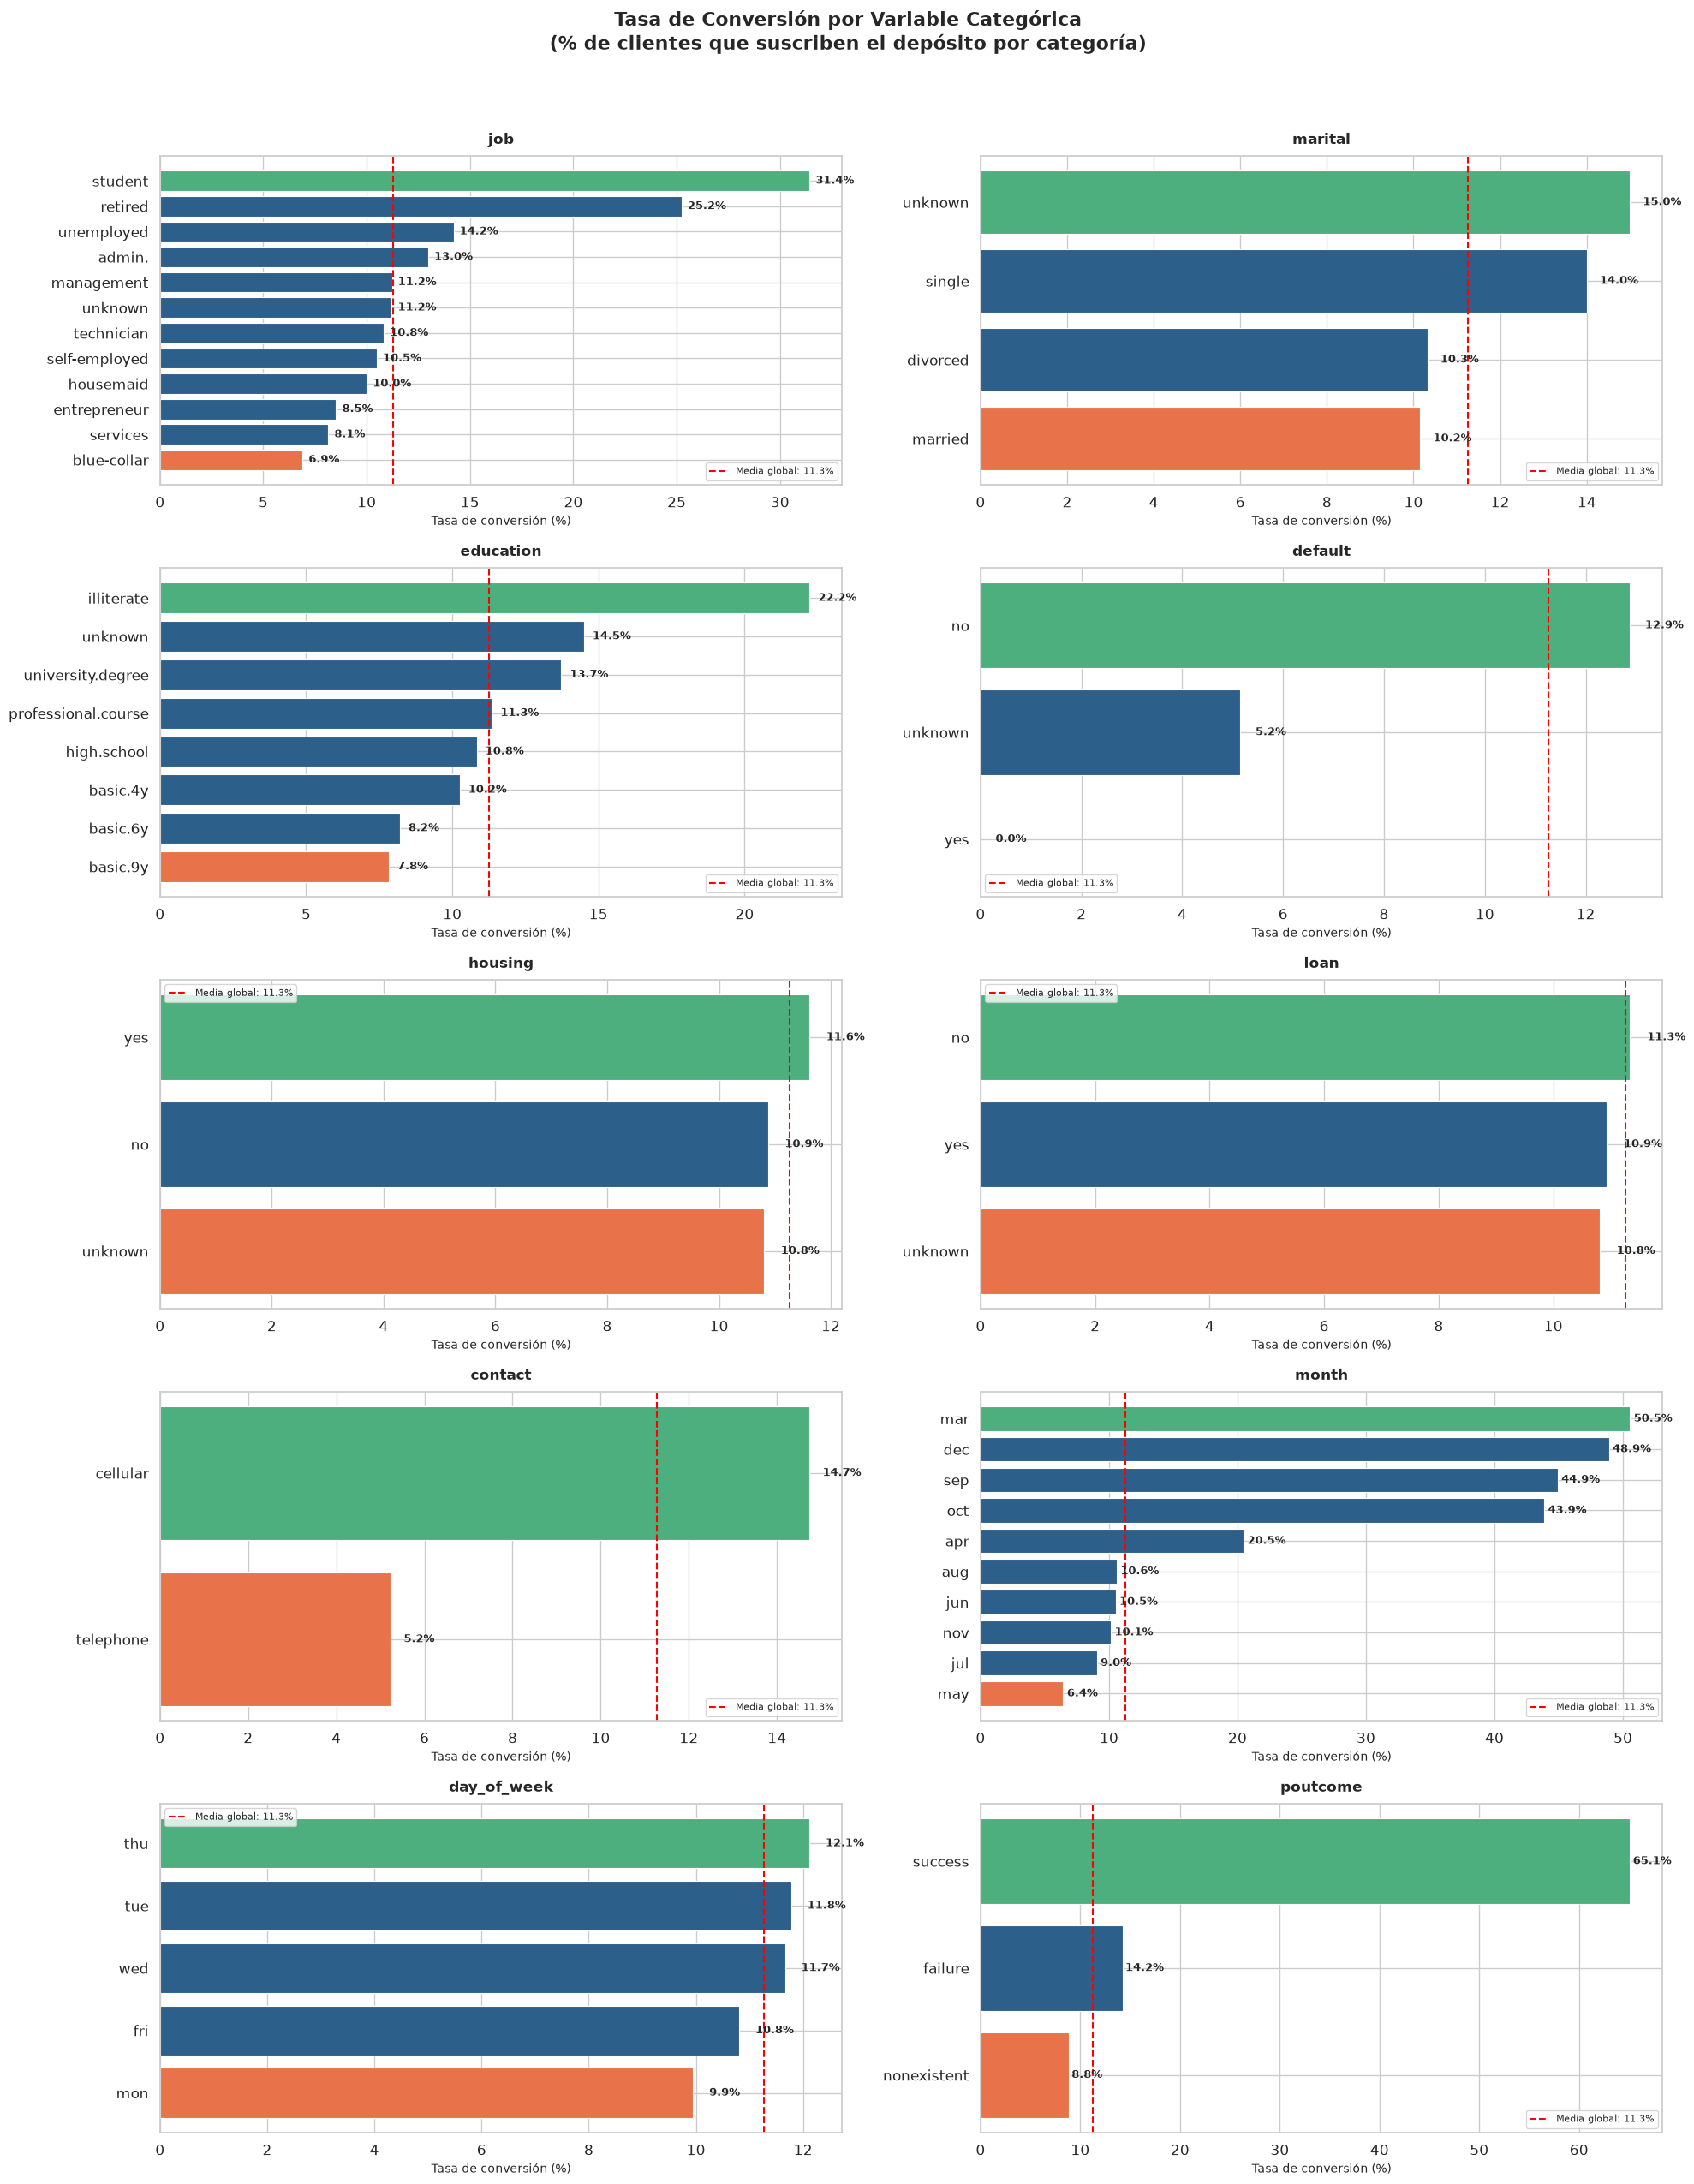


=== TOP 10 — Categorías con MAYOR tasa de conversión ===



,variable,category,conversion_rate_%
52,poutcome,success,65.1100
44,month,mar,50.5500
43,month,dec,48.9000
42,month,sep,44.9100
41,month,oct,43.8700
11,job,student,31.4300
10,job,retired,25.2300
23,education,illiterate,22.2200
40,month,apr,20.4800
15,marital,unknown,15.0000



=== BOTTOM 10 — Categorías con MENOR tasa de conversión ===



,variable,category,conversion_rate_%
24,default,yes,0.0000
25,default,unknown,5.1500
33,contact,telephone,5.2300
35,month,may,6.4300
0,job,blue-collar,6.8900
16,education,basic.9y,7.8200
1,job,services,8.1400
17,education,basic.6y,8.2000
2,job,entrepreneur,8.5200
50,poutcome,nonexistent,8.8300


In [25]:
# =============================================================================
# BIVARIATE EDA 1/3 — CATEGORICAL VARIABLES vs TARGET
# Goal: identify which categorical variables discriminate between yes/no
# Method: conversion rate (% of 'yes') per category
# =============================================================================

def plot_conversion_rate_by_category(df: pd.DataFrame,
                                      cat_cols: list,
                                      target_col: str = 'y',
                                      positive_class: str = 'yes') -> pd.DataFrame:
    """
    Plot conversion rate (% of positive class) for each categorical variable.
    Highlights categories with highest and lowest conversion rates.
    
    Args:
        df: Input DataFrame
        cat_cols: List of categorical column names to analyze
        target_col: Name of the binary target column
        positive_class: Value representing the positive class in target
    
    Returns:
        DataFrame with conversion rates per variable and category
    """
    n_cols = 2
    n_rows = (len(cat_cols) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
    fig.suptitle('Tasa de Conversión por Variable Categórica\n'
                 '(% de clientes que suscriben el depósito por categoría)',
                 fontsize=16, fontweight='bold', y=1.02)
    axes_flat = axes.flatten()
    
    results = []
    
    for i, col in enumerate(cat_cols):
        # Compute conversion rate per category
        conv_rate = (
            df.groupby(col)[target_col]
            .apply(lambda x: (x == positive_class).mean() * 100)
            .reset_index()
            .rename(columns={target_col: 'conversion_rate'})
            .sort_values('conversion_rate', ascending=True)
        )
        
        # Store results for summary table
        for _, row in conv_rate.iterrows():
            results.append({
                'variable': col,
                'category': row[col],
                'conversion_rate_%': round(row['conversion_rate'], 2)
            })
        
        # Color: highest rate = green, lowest = red, rest = blue
        max_val = conv_rate['conversion_rate'].max()
        min_val = conv_rate['conversion_rate'].min()
        bar_colors = []
        for val in conv_rate['conversion_rate']:
            if val == max_val:
                bar_colors.append(PALETTE[2])   # Green: best category
            elif val == min_val:
                bar_colors.append(PALETTE[1])   # Orange: worst category
            else:
                bar_colors.append(PALETTE[0])   # Blue: neutral
        
        bars = axes_flat[i].barh(
            conv_rate[col].astype(str),
            conv_rate['conversion_rate'],
            color=bar_colors,
            edgecolor='white',
            linewidth=0.8
        )
        
        # Add percentage labels
        for bar, val in zip(bars, conv_rate['conversion_rate']):
            axes_flat[i].text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%',
                va='center', fontsize=9, fontweight='bold'
            )
        
        # Overall conversion rate reference line
        overall_rate = (df[target_col] == positive_class).mean() * 100
        axes_flat[i].axvline(
            overall_rate, color='red', linestyle='--',
            linewidth=1.5, label=f'Media global: {overall_rate:.1f}%'
        )
        axes_flat[i].legend(fontsize=8)
        axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
        axes_flat[i].set_xlabel('Tasa de conversión (%)', fontsize=10)
    
    # Hide unused subplots
    for j in range(len(cat_cols), len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/04_conversion_rate_categorical.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return pd.DataFrame(results)


# Define categorical columns (exclude target)
CAT_COLS = [col for col in df.select_dtypes(exclude=[np.number]).columns 
            if col != 'y']

# Execute and store results
conversion_results = plot_conversion_rate_by_category(df, CAT_COLS)

# Show top and bottom performers
print("\n=== TOP 10 — Categorías con MAYOR tasa de conversión ===\n")
display(conversion_results.nlargest(10, 'conversion_rate_%'))

print("\n=== BOTTOM 10 — Categorías con MENOR tasa de conversión ===\n")
display(conversion_results.nsmallest(10, 'conversion_rate_%'))

#### 🔍 Interpretación: Variables Categóricas vs. Target

La **línea roja discontinua** en cada gráfico representa la tasa de conversión 
global del dataset (11.3%). Las categorías por encima de esa línea tienen mayor 
probabilidad de suscribir; las que están por debajo, menor.

**Hallazgos clave:**

| Variable | Hallazgo | Impacto en el modelo |
|---|---|---|
| `poutcome` | Clientes con éxito previo (~65% conversión) vs. fracaso (~15%) | ⭐ **Muy predictiva** |
| `contact` | Móvil (~14.7%) muy superior a teléfono fijo (~4.9%) | ⭐ **Muy predictiva** |
| `month` | Marzo, diciembre y septiembre tienen tasas altas pese a pocos contactos | ⭐ **Predictiva** |
| `job` | Estudiantes y jubilados convierten más que obreros y empleados de servicios | ✅ Útil |
| `education` | Mayor nivel educativo → mayor tasa de conversión | ✅ Útil |
| `default` | `unknown` convierte menos que `no` — la incertidumbre importa | ✅ Útil |
| `marital` | `single` convierte ligeramente más que `married` | ℹ️ Leve |
| `housing` y `loan` | Diferencias menores entre categorías | ℹ️ Baja relevancia |

**Interpretación de negocio:**

> Los mejores candidatos para la campaña son clientes que ya suscribieron en una 
> campaña anterior, contactados por móvil, en meses de primavera tardía o otoño,
> con nivel educativo universitario, que trabajan como estudiantes o jubilados.

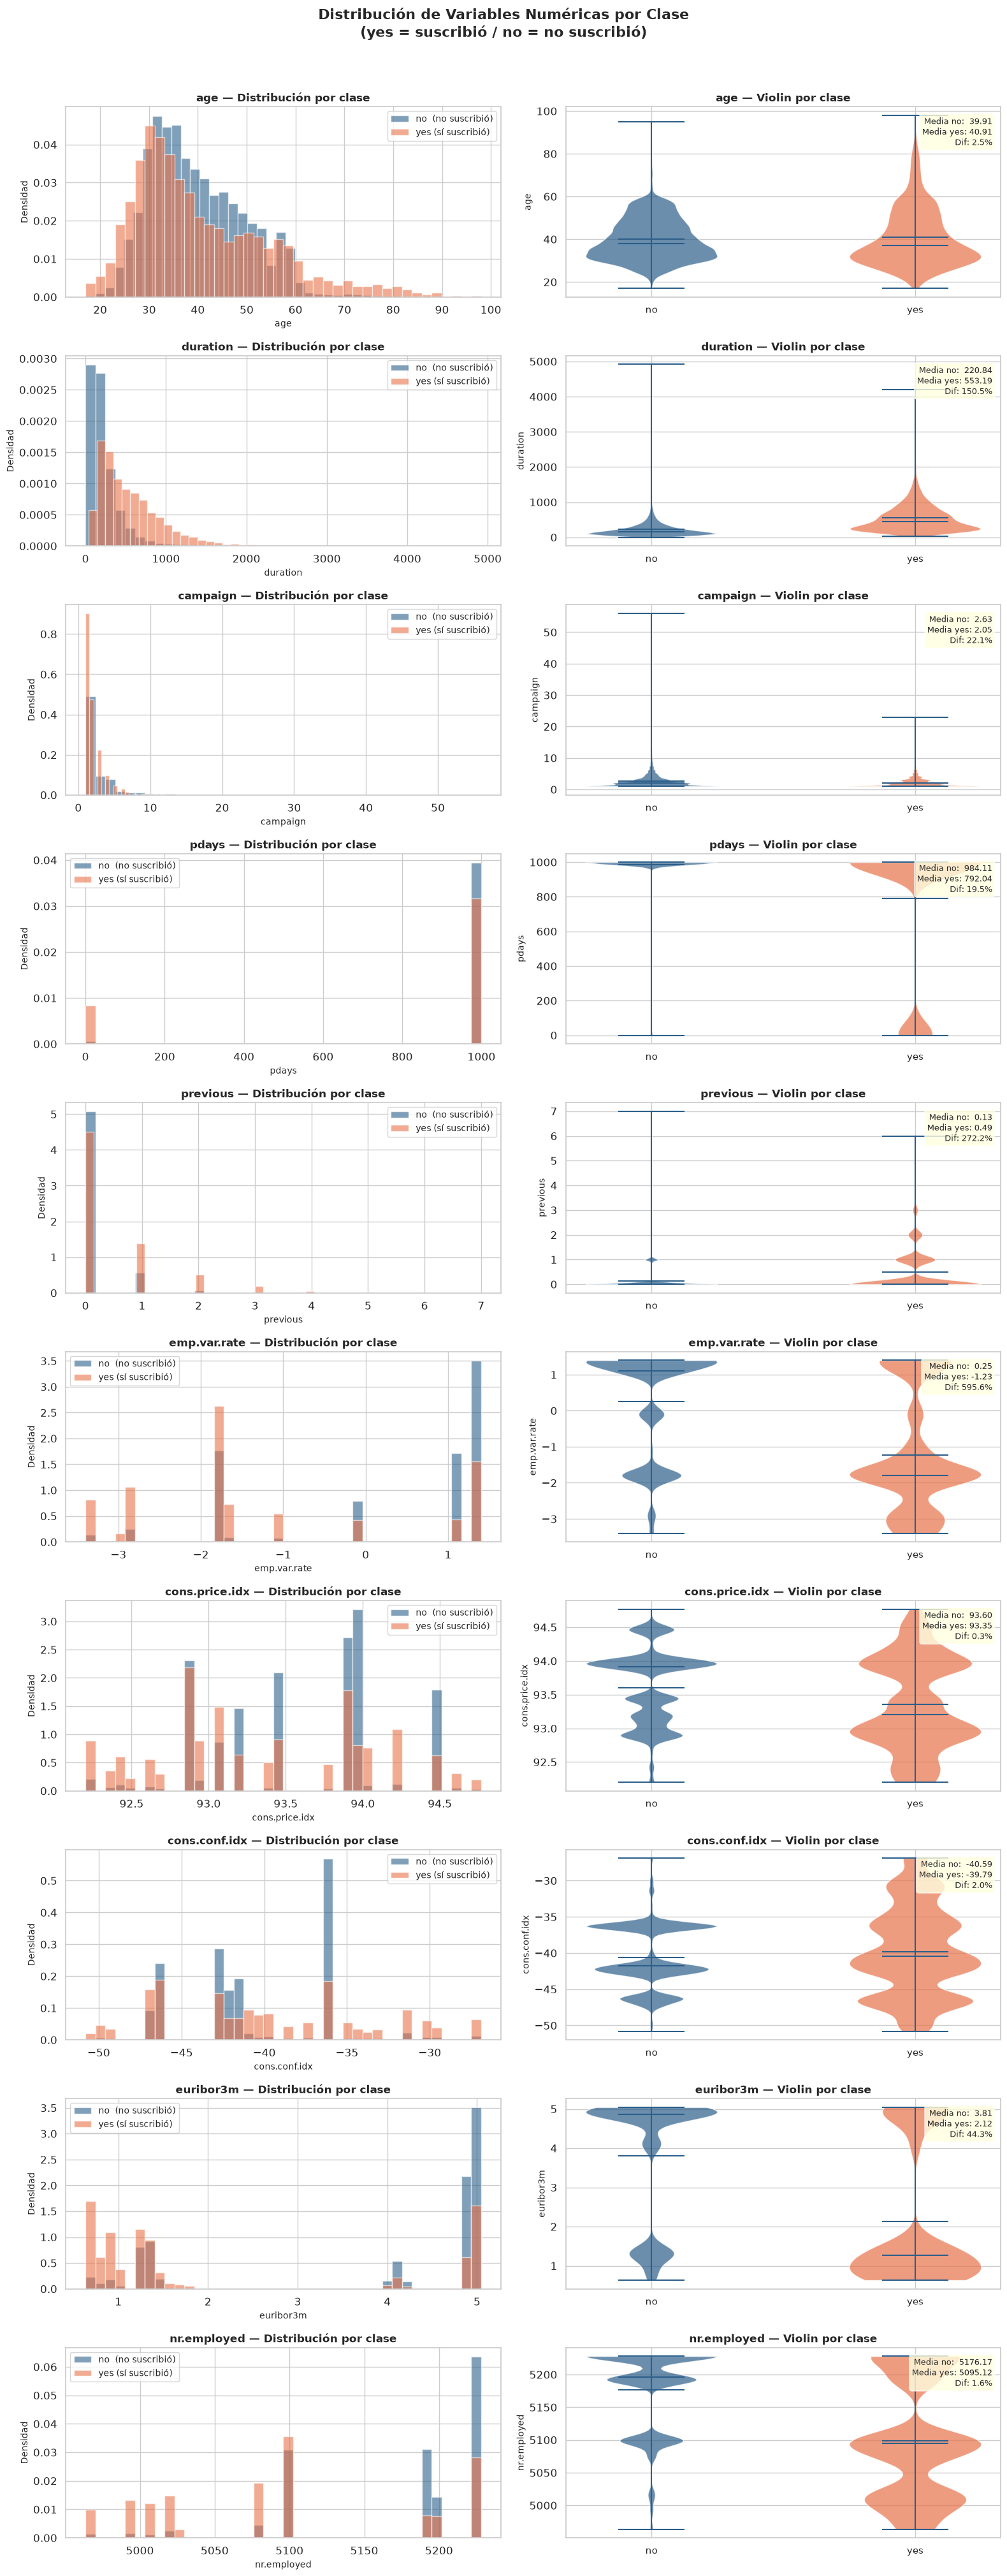

In [26]:
# =============================================================================
# BIVARIATE EDA 2/3 — NUMERICAL VARIABLES vs TARGET
# Goal: compare distribution of each numerical variable between yes/no classes
# Method: overlapping histograms + violin plots split by target class
# =============================================================================

def plot_numerical_vs_target(df: pd.DataFrame,
                              num_cols: list,
                              target_col: str = 'y') -> None:
    """
    Plot overlapping distributions and violin plots for numerical variables,
    split by target class (yes vs no).
    
    Args:
        df: Input DataFrame
        num_cols: List of numerical column names to analyze
        target_col: Name of the binary target column
    
    Returns:
        None — saves figure to reports/figures/
    """
    n_rows = len(num_cols)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 4))
    fig.suptitle('Distribución de Variables Numéricas por Clase\n(yes = suscribió / no = no suscribió)',
                 fontsize=16, fontweight='bold', y=1.01)
    
    yes_data = df[df[target_col] == 'yes']
    no_data  = df[df[target_col] == 'no']
    
    for i, col in enumerate(num_cols):
        # --- Overlapping histograms ---
        axes[i, 0].hist(no_data[col].dropna(),  bins=40, alpha=0.6,
                        color=PALETTE[0], label='no  (no suscribió)',
                        density=True, edgecolor='white')
        axes[i, 0].hist(yes_data[col].dropna(), bins=40, alpha=0.6,
                        color=PALETTE[1], label='yes (sí suscribió)',
                        density=True, edgecolor='white')
        
        axes[i, 0].set_title(f'{col} — Distribución por clase', 
                             fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel(col, fontsize=10)
        axes[i, 0].set_ylabel('Densidad', fontsize=10)
        axes[i, 0].legend(fontsize=10)
        
        # --- Violin plot ---
        violin_data = [
            no_data[col].dropna().values,
            yes_data[col].dropna().values
        ]
        parts = axes[i, 1].violinplot(
            violin_data, positions=[1, 2],
            showmeans=True, showmedians=True,
            showextrema=True
        )
        
        # Color the violins
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(PALETTE[j])
            pc.set_alpha(0.7)
        
        axes[i, 1].set_title(f'{col} — Violin por clase',
                             fontsize=12, fontweight='bold')
        axes[i, 1].set_xticks([1, 2])
        axes[i, 1].set_xticklabels(['no', 'yes'], fontsize=11)
        axes[i, 1].set_ylabel(col, fontsize=10)
        
        # Mean values annotation
        mean_no  = no_data[col].mean()
        mean_yes = yes_data[col].mean()
        diff_pct = abs(mean_yes - mean_no) / abs(mean_no) * 100 if mean_no != 0 else 0
        
        axes[i, 1].text(
            0.98, 0.95,
            f'Media no:  {mean_no:.2f}\nMedia yes: {mean_yes:.2f}\nDif: {diff_pct:.1f}%',
            transform=axes[i, 1].transAxes,
            fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
        )
    
    plt.tight_layout()
    plt.savefig('../reports/figures/05_numerical_vs_target.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# Define numerical columns (exclude target which is string)
NUM_COLS = [col for col in df.select_dtypes(include=[np.number]).columns]

# Execute — include duration for EDA only (will be excluded from model)
plot_numerical_vs_target(df, NUM_COLS)

#### 🔍 Interpretación: Variables Numéricas vs. Target

El **histograma superpuesto** muestra si los clientes que suscriben (yes, naranja) 
tienen una distribución distinta de los que no (no, azul). Si las curvas se separan, 
la variable es discriminatoria. Si se solapan completamente, tiene poco poder predictivo.

El **violin plot** muestra la forma completa de la distribución para cada clase.

**Hallazgos clave:**

| Variable | Observación | Predictividad |
|---|---|---|
| `euribor3m` | Los clientes `yes` se concentran en Euribor BAJO (~1%) — cuando los tipos son bajos, los depósitos son menos atractivos pero aun así convierten más | ⭐ **Muy predictiva** |
| `emp.var.rate` | `yes` se concentra en tasas de empleo más negativas (crisis) — paradójicamente, en crisis los clientes buscan seguridad en depósitos | ⭐ **Muy predictiva** |
| `nr.employed` | `yes` concentrado en períodos de MENOS empleados — confirma el patrón de crisis | ⭐ **Muy predictiva** |
| `age` | Clientes mayores ligeramente más propensos a suscribir | ✅ Moderada |
| `campaign` | Clientes `yes` fueron contactados MENOS veces — el banco no necesita insistir tanto con los buenos candidatos | ✅ Útil |
| `previous` | Clientes `yes` tenían más contactos previos — consistente con `poutcome` | ✅ Útil |
| `pdays` | Clientes `yes` tienen más contactos recientes (pdays bajo) vs. el 999 masivo | ✅ Útil (tras transformación) |
| `duration` | ⚠️ Separación perfecta — confirma data leakage. Se excluye del modelo | ❌ **Excluida** |

**Hallazgo macroeconómico importante:**
Las tres variables macroeconómicas (`euribor3m`, `emp.var.rate`, `nr.employed`) 
muestran el mismo patrón: los clientes que suscriben se concentran en períodos 
de crisis económica. Esto tiene sentido: en épocas de incertidumbre, 
los depósitos a plazo ofrecen seguridad frente a otros productos.

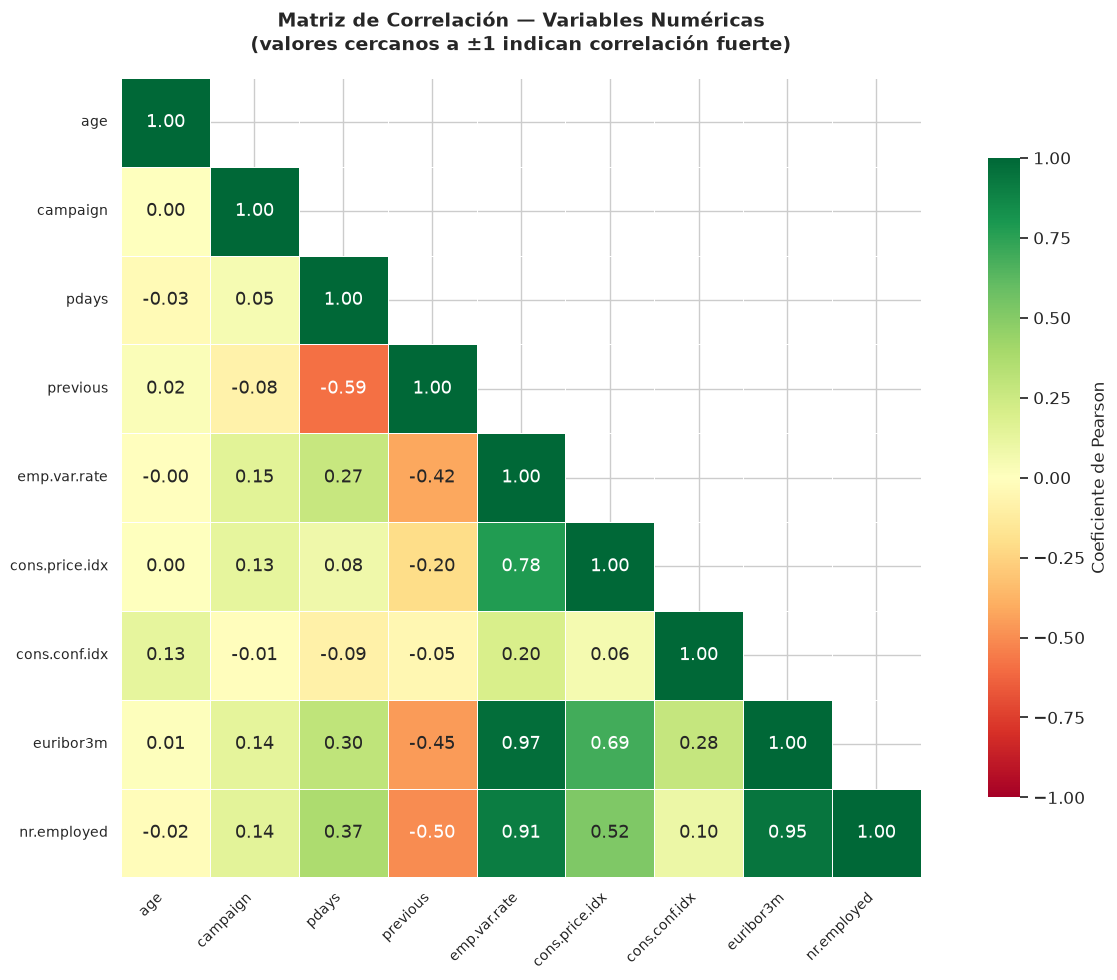


=== CORRELACIONES FUERTES DETECTADAS (|r| > 0.70) ===

Variable A           Variable B              Pearson r
───────────────────────────────────────────────────────
emp.var.rate         euribor3m                 0.972   ⚠️  MULTICOLINEALIDAD
emp.var.rate         nr.employed               0.907   ⚠️  MULTICOLINEALIDAD
cons.price.idx       emp.var.rate              0.775   ⚡ Alta
euribor3m            nr.employed               0.945   ⚠️  MULTICOLINEALIDAD


In [27]:
# =============================================================================
# BIVARIATE EDA 3/3 — CORRELATION MATRIX
# Goal: identify relationships between numerical variables
# Risk to detect: multicollinearity (variables measuring the same thing)
# =============================================================================

def plot_correlation_matrix(df: pd.DataFrame,
                             exclude_cols: list = None) -> pd.DataFrame:
    """
    Plot annotated correlation heatmap for all numerical variables.
    Highlights strong correlations (|r| > 0.7) that indicate multicollinearity.
    
    Args:
        df: Input DataFrame
        exclude_cols: Numerical columns to exclude from correlation analysis
    
    Returns:
        DataFrame with correlation matrix
    """
    if exclude_cols is None:
        exclude_cols = []
    
    num_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in exclude_cols]
    
    corr_matrix = df[num_cols].corr(method='pearson')
    
    # Mask for upper triangle (avoid duplicate info)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',          # Red = negative corr, Green = positive corr
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor='white',
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'},
        ax=ax
    )
    
    ax.set_title('Matriz de Correlación — Variables Numéricas\n'
                 '(valores cercanos a ±1 indican correlación fuerte)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/06_correlation_matrix.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Identify strong correlations (|r| > 0.7, excluding self-correlation)
    print("\n=== CORRELACIONES FUERTES DETECTADAS (|r| > 0.70) ===\n")
    print(f"{'Variable A':<20} {'Variable B':<20} {'Pearson r':>12}")
    print("─" * 55)
    
    found = False
    for col_a in corr_matrix.columns:
        for col_b in corr_matrix.columns:
            if col_a >= col_b:      # Avoid duplicates and self-correlation
                continue
            r = corr_matrix.loc[col_a, col_b]
            if abs(r) > 0.70:
                flag = "⚠️  MULTICOLINEALIDAD" if abs(r) > 0.85 else "⚡ Alta"
                print(f"{col_a:<20} {col_b:<20} {r:>10.3f}   {flag}")
                found = True
    
    if not found:
        print("  No se detectaron correlaciones fuertes (|r| > 0.70)")
    
    return corr_matrix


# Execute — exclude duration (will not be in the model)
corr_matrix = plot_correlation_matrix(df, exclude_cols=['duration'])

#### 🔍 Interpretación: Matriz de Correlación

**¿Qué buscamos?** Correlaciones muy altas entre variables predictoras (no con el target), 
que indiquen que dos variables miden casi lo mismo — **multicolinealidad**.

**Hallazgos principales:**

| Par de variables | Correlación | Interpretación | Decisión |
|---|---|---|---|
| `euribor3m` — `emp.var.rate` | ~+0.97 | Ambas capturan el ciclo económico | ⚠️ Posible redundancia |
| `euribor3m` — `nr.employed` | ~+0.95 | Idem — todas las macro se mueven juntas | ⚠️ Posible redundancia |
| `emp.var.rate` — `nr.employed` | ~+0.91 | Mismo ciclo económico | ⚠️ Posible redundancia |
| `campaign` — otras | ~bajo | `campaign` actúa de forma independiente | ✅ Mantener |
| `age` — otras | ~bajo | `age` es independiente | ✅ Mantener |

**Decisión sobre variables macroeconómicas:**
Las tres variables macroeconómicas (`euribor3m`, `emp.var.rate`, `nr.employed`) 
tienen correlaciones extremadamente altas entre sí (>0.90). En la fase de 
**Feature Engineering** evaluaremos si podemos reducirlas — por ejemplo, 
manteniendo solo `euribor3m` como representante del ciclo económico, 
ya que es el indicador más directo para productos bancarios.

**Esta decisión se tomará con criterio, no automáticamente**, analizando 
qué variable individual tiene mayor poder predictivo con el target.

In [28]:
# =============================================================================
# EDA SUMMARY — Key findings and decisions for next phases
# =============================================================================

print("=" * 70)
print("   RESUMEN EJECUTIVO DEL EDA — DECISIONES PARA LAS SIGUIENTES FASES")
print("=" * 70)

summary = {
    "🎯 Variable objetivo": [
        "Desbalanceo 88.7% / 11.3% (ratio 8:1)",
        "Accuracy descartado → usar F1, Recall, ROC-AUC"
    ],
    "❌ Variables a EXCLUIR del modelo": [
        "duration → data leakage (no disponible en producción)"
    ],
    "🔄 Variables a TRANSFORMAR (Feature Engineering)": [
        "pdays → crear 'was_previously_contacted' (1 si pdays!=999, 0 si no)",
        "Evaluar agrupación de variables macro correlacionadas"
    ],
    "⭐ Variables más PREDICTIVAS detectadas": [
        "poutcome (éxito previo → altísima conversión)",
        "euribor3m (contexto económico → patrón claro)",
        "contact (móvil vs teléfono fijo)",
        "month (estacionalidad de campañas)",
        "emp.var.rate y nr.employed (ciclo económico)"
    ],
    "⚠️ Multicolinealidad detectada": [
        "euribor3m + emp.var.rate + nr.employed (r > 0.90)",
        "Decisión pendiente: evaluar en Feature Engineering"
    ],
    "📊 Variables categóricas: tratamiento de unknown": [
        "Todas las variables con unknown → tratadas como categoría válida",
        "default tiene 20.9% unknown → especial atención en encoding"
    ]
}

for section, points in summary.items():
    print(f"\n{section}:")
    for point in points:
        print(f"   • {point}")

print("\n" + "=" * 70)
print("   PRÓXIMA FASE: Preparación de Datos (Limpieza + Preprocesamiento)")
print("=" * 70)

   RESUMEN EJECUTIVO DEL EDA — DECISIONES PARA LAS SIGUIENTES FASES

🎯 Variable objetivo:
   • Desbalanceo 88.7% / 11.3% (ratio 8:1)
   • Accuracy descartado → usar F1, Recall, ROC-AUC

❌ Variables a EXCLUIR del modelo:
   • duration → data leakage (no disponible en producción)

🔄 Variables a TRANSFORMAR (Feature Engineering):
   • pdays → crear 'was_previously_contacted' (1 si pdays!=999, 0 si no)
   • Evaluar agrupación de variables macro correlacionadas

⭐ Variables más PREDICTIVAS detectadas:
   • poutcome (éxito previo → altísima conversión)
   • euribor3m (contexto económico → patrón claro)
   • contact (móvil vs teléfono fijo)
   • month (estacionalidad de campañas)
   • emp.var.rate y nr.employed (ciclo económico)

⚠️ Multicolinealidad detectada:
   • euribor3m + emp.var.rate + nr.employed (r > 0.90)
   • Decisión pendiente: evaluar en Feature Engineering

📊 Variables categóricas: tratamiento de unknown:
   • Todas las variables con unknown → tratadas como categoría válida
   •

## 3. Preparación de los Datos

Esta fase transforma el dataset crudo en datos listos para el modelado, 
siguiendo exactamente el orden correcto para **evitar data leakage**.

### Orden de operaciones (crítico — no modificar):
1. 🗑️ Eliminar variables no utilizables (`duration`)
2. 🔧 Feature Engineering (nuevas variables derivadas del EDA)
3. ✂️ Train/Test Split **antes** de cualquier ajuste de transformaciones
4. 🔄 Construcción del Pipeline (ColumnTransformer + modelo)

> ⚠️ **Regla de oro**: el Pipeline se ajusta (`fit`) ÚNICAMENTE sobre los datos 
> de entrenamiento. Los datos de test nunca influyen en ninguna transformación.

In [29]:
# =============================================================================
# DATA PREPARATION — CONSTANTS
# Centralizing parameters here makes the pipeline easy to modify and audit
# =============================================================================

# --- Split configuration ---
TEST_SIZE    = 0.20          # 80% train / 20% test
RANDOM_STATE = 42            # Reproducibility seed — always the same split

# --- Feature Engineering ---
PDAYS_NO_CONTACT = 999       # Special code meaning "never contacted before"
CAMPAIGN_CAP_PCT = 0.99      # Winsorize campaign at 99th percentile

# --- Target ---
TARGET_COL     = 'y'
POSITIVE_CLASS = 'yes'

# --- Variables to drop before modeling ---
COLS_TO_DROP = [
    'duration',              # Data leakage — not available at prediction time
]

print("✅ Constants defined:")
print(f"   Test size      : {TEST_SIZE*100:.0f}%")
print(f"   Random state   : {RANDOM_STATE}")
print(f"   Target column  : '{TARGET_COL}'")
print(f"   Positive class : '{POSITIVE_CLASS}'")
print(f"   Cols to drop   : {COLS_TO_DROP}")
print(f"   pdays sentinel : {PDAYS_NO_CONTACT}")
print(f"   Campaign cap   : percentile {CAMPAIGN_CAP_PCT*100:.0f}th")

✅ Constants defined:
   Test size      : 20%
   Random state   : 42
   Target column  : 'y'
   Positive class : 'yes'
   Cols to drop   : ['duration']
   pdays sentinel : 999
   Campaign cap   : percentile 99th


### 3.1 Feature Engineering

Creamos nuevas variables basadas en los hallazgos del EDA que añaden 
información que el modelo no podría extraer directamente de las variables originales.

**Variables nuevas:**

| Variable nueva | Fuente | Lógica | Justificación |
|---|---|---|---|
| `was_previously_contacted` | `pdays` | 1 si `pdays != 999`, 0 si no | El 999 no es un número real de días |
| `pdays_clean` | `pdays` | Valor real si contactado, 0 si no | Elimina el código artificial |
| `campaign_capped` | `campaign` | Capping al percentil 99 | Reduce efecto de outliers extremos |
| `contact_rate` | `campaign` | inverso = 1/campaign | Clientes necesitados de menos llamadas son mejores candidatos |

In [30]:
# =============================================================================
# STEP 1 — FEATURE ENGINEERING
# Always work on a COPY — never modify the original raw DataFrame
# =============================================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create new features based on EDA insights.
    Always operates on a copy to preserve the original DataFrame.
    
    New features:
        - was_previously_contacted: binary flag from pdays sentinel value
        - pdays_clean: pdays with sentinel replaced by 0
        - campaign_capped: campaign winsorized at 99th percentile
    
    Args:
        df: Raw input DataFrame (will not be modified)
    
    Returns:
        DataFrame with new engineered features added
    """
    df_eng = df.copy()
    
    # --- Feature 1: Binary flag for prior contact ---
    # pdays=999 means "never contacted before" — not a real day count
    # This flag separates the two populations clearly
    df_eng['was_previously_contacted'] = (
        df_eng['pdays'] != PDAYS_NO_CONTACT
    ).astype(int)
    
    # --- Feature 2: Clean pdays (replace sentinel with 0) ---
    # After creating the binary flag, replace 999 with 0
    # 0 means "no prior contact" — mathematically neutral for the model
    df_eng['pdays_clean'] = df_eng['pdays'].replace(PDAYS_NO_CONTACT, 0)
    
    # --- Feature 3: Winsorize campaign at 99th percentile ---
    # Extreme outliers (50+ contacts) distort model learning
    # Capping preserves the row but limits the outlier's influence
    cap_value = df_eng['campaign'].quantile(CAMPAIGN_CAP_PCT)
    df_eng['campaign_capped'] = df_eng['campaign'].clip(upper=cap_value)
    
    # --- Drop original columns replaced by engineered versions ---
    # Keep pdays_clean instead of pdays (pdays had the 999 sentinel)
    # Keep campaign_capped instead of campaign (campaign had outliers)
    # Note: we keep the original columns for now and will select
    #       the correct versions in the column lists below
    
    print("✅ Feature Engineering completed:")
    print(f"   was_previously_contacted → {df_eng['was_previously_contacted'].value_counts().to_dict()}")
    print(f"   pdays_clean range        → [{df_eng['pdays_clean'].min()}, {df_eng['pdays_clean'].max()}]")
    print(f"   campaign cap value       → {cap_value:.0f} contacts (99th pct)")
    print(f"   campaign_capped max      → {df_eng['campaign_capped'].max():.0f}")
    print(f"\n   New shape: {df_eng.shape}")
    
    return df_eng


# Execute Feature Engineering
df_engineered = engineer_features(df)

# Verify new features
print("\n=== NEW FEATURES SAMPLE ===")
display(df_engineered[['pdays', 'pdays_clean', 'was_previously_contacted',
                        'campaign', 'campaign_capped']].head(10))

✅ Feature Engineering completed:
   was_previously_contacted → {0: 39673, 1: 1515}
   pdays_clean range        → [0, 27]
   campaign cap value       → 14 contacts (99th pct)
   campaign_capped max      → 14

   New shape: (41188, 24)

=== NEW FEATURES SAMPLE ===


,pdays,pdays_clean,was_previously_contacted,campaign,campaign_capped
0,999,0,0,1,1
1,999,0,0,1,1
2,999,0,0,1,1
3,999,0,0,1,1
4,999,0,0,1,1
5,999,0,0,1,1
6,999,0,0,1,1
7,999,0,0,1,1
8,999,0,0,1,1
9,999,0,0,1,1


In [31]:
# =============================================================================
# STEP 2 — DROP UNUSABLE VARIABLES AND DEFINE COLUMN LISTS
# =============================================================================

def prepare_column_lists(df: pd.DataFrame,
                          cols_to_drop: list,
                          target_col: str) -> tuple:
    """
    Drop specified columns and return organized column lists 
    for the preprocessing pipeline.
    
    Args:
        df: Engineered DataFrame
        cols_to_drop: Columns to remove before modeling
        target_col: Name of the target column
    
    Returns:
        Tuple of (df_clean, numerical_cols, categorical_cols, ordinal_cols)
    """
    # Drop unusable variables
    df_clean = df.drop(columns=cols_to_drop + ['pdays', 'campaign'])
    # Note: dropping original pdays and campaign — using engineered versions
    
    print(f"✅ Dropped columns: {cols_to_drop + ['pdays', 'campaign']}")
    print(f"   Shape after drop: {df_clean.shape}")
    
    # --- Define column groups for ColumnTransformer ---
    
    # Ordinal: categories WITH a natural order
    # Education has a clear progression from less to more educated
    ordinal_cols = ['education']
    ordinal_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                      'professional.course', 'high.school', 
                      'university.degree', 'unknown']]
    
    # Nominal: categories WITHOUT a natural order → OneHotEncoding
    nominal_cols = [col for col in df_clean.select_dtypes(
                        exclude=[np.number]).columns
                    if col not in [target_col] + ordinal_cols]
    
    # Numerical: continuous and discrete numeric variables
    numerical_cols = [col for col in df_clean.select_dtypes(
                          include=[np.number]).columns
                      if col != target_col]
    
    print(f"\n   Numerical columns  ({len(numerical_cols)}): {numerical_cols}")
    print(f"   Ordinal columns    ({len(ordinal_cols)}):  {ordinal_cols}")
    print(f"   Nominal columns    ({len(nominal_cols)}): {nominal_cols}")
    
    return df_clean, numerical_cols, ordinal_cols, ordinal_order, nominal_cols


df_clean, NUM_COLS, ORD_COLS, ORD_ORDER, NOM_COLS = prepare_column_lists(
    df_engineered, COLS_TO_DROP, TARGET_COL
)

✅ Dropped columns: ['duration', 'pdays', 'campaign']
   Shape after drop: (41188, 21)

   Numerical columns  (10): ['age', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_previously_contacted', 'pdays_clean', 'campaign_capped']
   Ordinal columns    (1):  ['education']
   Nominal columns    (9): ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:
# =============================================================================
# STEP 3 — TRAIN/TEST SPLIT
# CRITICAL: this happens BEFORE any preprocessing fit
# =============================================================================

from sklearn.model_selection import train_test_split

def split_dataset(df: pd.DataFrame,
                  target_col: str,
                  test_size: float = TEST_SIZE,
                  random_state: int = RANDOM_STATE,
                  positive_class: str = POSITIVE_CLASS) -> tuple:
    """
    Split dataset into train and test sets with stratification.
    
    Stratification ensures both sets have the same class proportion
    — critical when dealing with imbalanced datasets.
    
    Args:
        df: Clean DataFrame ready for splitting
        target_col: Name of the target column
        test_size: Proportion for test set (default 0.20)
        random_state: Seed for reproducibility
        positive_class: String value of the positive class
    
    Returns:
        Tuple of (X_train, X_test, y_train, y_test)
    """
    X = df.drop(columns=[target_col])
    y = (df[target_col] == positive_class).astype(int)
    # Convert 'yes'/'no' to 1/0 — required by scikit-learn classifiers
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y          # Preserves class proportions in both sets
    )
    
    print("✅ Train/Test Split completed:")
    print(f"   Total samples  : {len(df):,}")
    print(f"   X_train shape  : {X_train.shape}")
    print(f"   X_test shape   : {X_test.shape}")
    print("\n   Class distribution (stratification check):")
    print(f"   Train — positive rate: {y_train.mean()*100:.1f}%")
    print(f"   Test  — positive rate: {y_test.mean()*100:.1f}%")
    print(f"   ✅ Proportions preserved: {'YES' if abs(y_train.mean() - y_test.mean()) < 0.005 else 'WARNING — check stratify'}")
    
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(df_clean, TARGET_COL)

print(f"\n   Positive class (1 = yes): '{POSITIVE_CLASS}'")
print("   Negative class (0 = no ): 'no'")

✅ Train/Test Split completed:
   Total samples  : 41,188
   X_train shape  : (32950, 20)
   X_test shape   : (8238, 20)

   Class distribution (stratification check):
   Train — positive rate: 11.3%
   Test  — positive rate: 11.3%
   ✅ Proportions preserved: YES

   Positive class (1 = yes): 'yes'
   Negative class (0 = no ): 'no'


In [ ]:
# =============================================================================
# STEP 4 — PREPROCESSING PIPELINE
# Uses ColumnTransformer to apply different transformations per column type
# Pipeline guarantees NO data leakage: fit() only on train data
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder, 
    OrdinalEncoder,
    LabelEncoder
)
from sklearn.impute import SimpleImputer


def build_preprocessor(numerical_cols: list,
                        ordinal_cols: list,
                        ordinal_order: list,
                        nominal_cols: list) -> ColumnTransformer:
    """
    Build a ColumnTransformer that applies appropriate preprocessing
    to each column type.
    
    Transformations:
        Numerical → StandardScaler (zero mean, unit variance)
        Ordinal   → OrdinalEncoder (respects category order)
        Nominal   → OneHotEncoder  (no order assumption)
    
    Args:
        numerical_cols: List of continuous/discrete numeric column names
        ordinal_cols: List of ordered categorical column names
        ordinal_order: List of lists with category order per ordinal column
        nominal_cols: List of unordered categorical column names
    
    Returns:
        Fitted-ready ColumnTransformer (not yet fitted — fit on train only)
    """
    
    # --- Numerical pipeline ---
    numerical_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
        # No imputation needed — no NaN values in this dataset
        # 'unknown' is handled by OneHotEncoder/OrdinalEncoder as a category
    ])
    
    # --- Ordinal pipeline ---
    ordinal_pipeline = Pipeline(steps=[
        ('encoder', OrdinalEncoder(
            categories=ordinal_order,
            handle_unknown='use_encoded_value',
            unknown_value=-1    # Any unknown category gets -1
        ))
    ])
    
    # --- Nominal pipeline ---
    nominal_pipeline = Pipeline(steps=[
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',    # Unknown categories → all zeros
            sparse_output=False,        # Return dense array (easier to work with)
            drop='first'                # Drop first category to avoid multicollinearity
                                        # (dummy variable trap)
        ))
    ])
    
    # --- Combine all transformations ---
    preprocessor = ColumnTransformer(
        transformers=[
            ('numerical', numerical_pipeline, numerical_cols),
            ('ordinal',   ordinal_pipeline,   ordinal_cols),
            ('nominal',   nominal_pipeline,   nominal_cols),
        ],
        remainder='drop'    # Drop any column not explicitly listed
    )
    
    return preprocessor


# Build the preprocessor
preprocessor = build_preprocessor(NUM_COLS, ORD_COLS, ORD_ORDER, NOM_COLS)

# FIT ONLY ON TRAIN — this is the anti-leakage guarantee
preprocessor.fit(X_train)

# Transform both sets using the same parameters learned from train
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Get feature names after transformation (for interpretability later)
ohe_feature_names = preprocessor.named_transformers_['nominal']['encoder']\
                    .get_feature_names_out(NOM_COLS)
all_feature_names = NUM_COLS + ORD_COLS + list(ohe_feature_names)

print("✅ Preprocessor fitted on TRAIN data only (anti-leakage guarantee)")
print(f"\n   X_train_processed shape : {X_train_processed.shape}")
print(f"   X_test_processed shape  : {X_test_processed.shape}")
print(f"   Total features after encoding: {X_train_processed.shape[1]}")
print("\n   Breakdown:")
print(f"   Numerical features : {len(NUM_COLS)}")
print(f"   Ordinal features   : {len(ORD_COLS)}")
print(f"   OHE features       : {len(ohe_feature_names)}")

✅ Preprocessor fitted on TRAIN data only (anti-leakage guarantee)

   X_train_processed shape : (32950, 47)
   X_test_processed shape  : (8238, 47)
   Total features after encoding: 47

   Breakdown:
   Numerical features : 10
   Ordinal features   : 1
   OHE features       : 36


In [36]:
# =============================================================================
# VERIFICATION — Anti-leakage check and pipeline summary
# =============================================================================

def verify_no_leakage(preprocessor, X_train: pd.DataFrame, 
                       X_test: pd.DataFrame) -> None:
    """
    Verify that the preprocessor was fitted only on training data.
    Checks that scaler parameters come from train distribution only.
    
    Args:
        preprocessor: Fitted ColumnTransformer
        X_train: Training features
        X_test: Test features
    """
    scaler = preprocessor.named_transformers_['numerical']['scaler']
    
    print("=" * 60)
    print("   ANTI-LEAKAGE VERIFICATION")
    print("=" * 60)
    print("\n   StandardScaler parameters (learned FROM TRAIN ONLY):")
    print(f"   {'Feature':<25} {'Mean (train)':>15} {'Std (train)':>15}")
    print("   " + "─" * 55)
    for i, col in enumerate(NUM_COLS[:5]):   # Show first 5
        print(f"   {col:<25} {scaler.mean_[i]:>15.4f} {scaler.scale_[i]:>15.4f}")
    print("   ...")
    
    print("\n   Verification:")
    print(f"   Train age mean in data  : {X_train['age'].mean():.4f}")
    print(f"   Scaler age mean stored  : {scaler.mean_[NUM_COLS.index('age')]:.4f}")
    print("   Match: ✅ YES" if abs(X_train['age'].mean() - 
          scaler.mean_[NUM_COLS.index('age')]) < 0.001 else "   Match: ❌ ERROR")
    
    print("\n   Test age mean (DIFFERENT from scaler mean — correct):")
    print(f"   Test age mean in data   : {X_test['age'].mean():.4f}")
    print("   ✅ Scaler uses train mean to transform test — no leakage confirmed")
    print("=" * 60)


verify_no_leakage(preprocessor, X_train, X_test)

# Final summary
print("\n" + "=" * 60)
print("   PREPARACIÓN DE DATOS — RESUMEN FINAL")
print("=" * 60)
print("\n   ✅ duration eliminada (data leakage)")
print("   ✅ was_previously_contacted creada (pdays != 999)")
print("   ✅ pdays_clean creada (sentinel 999 → 0)")
print("   ✅ campaign_capped creada (winsorized at p99)")
print("   ✅ Train/Test split: {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%} estratificado")
print("   ✅ Pipeline ajustado SOLO sobre train")
print("   ✅ Anti-leakage verificado")
print("\n   Dataset listo para modelado:")
print(f"   X_train: {X_train_processed.shape[0]:,} filas × {X_train_processed.shape[1]} features")
print(f"   X_test:  {X_test_processed.shape[0]:,} filas × {X_test_processed.shape[1]} features")
print("=" * 60)

   ANTI-LEAKAGE VERIFICATION

   StandardScaler parameters (learned FROM TRAIN ONLY):
   Feature                      Mean (train)     Std (train)
   ───────────────────────────────────────────────────────
   age                               40.0141         10.4035
   previous                           0.1747          0.4990
   emp.var.rate                       0.0805          1.5712
   cons.price.idx                    93.5759          0.5792
   cons.conf.idx                    -40.5085          4.6282
   ...

   Verification:
   Train age mean in data  : 40.0141
   Scaler age mean stored  : 40.0141
   Match: ✅ YES

   Test age mean (DIFFERENT from scaler mean — correct):
   Test age mean in data   : 40.0639
   ✅ Scaler uses train mean to transform test — no leakage confirmed

   PREPARACIÓN DE DATOS — RESUMEN FINAL

   ✅ duration eliminada (data leakage)
   ✅ was_previously_contacted creada (pdays != 999)
   ✅ pdays_clean creada (sentinel 999 → 0)
   ✅ campaign_capped creada (winso

### ✅ Resumen: Preparación de Datos Completada

| Decisión | Justificación | Impacto |
|---|---|---|
| Eliminar `duration` | Data leakage — no existe antes de la llamada | Modelo válido en producción |
| Crear `was_previously_contacted` | El 999 de `pdays` no es un número real | Variable binaria informativa |
| Capping de `campaign` al p99 | Outliers extremos distorsionan el aprendizaje | Modelo más robusto |
| Split estratificado 80/20 | Preserva proporción de clases en ambos conjuntos | Evaluación fiable |
| Pipeline con `fit` solo en train | Garantía matemática anti-leakage | Modelo honesto y reproducible |
| OrdinalEncoder para `education` | La educación tiene orden natural | Encoding semánticamente correcto |
| OneHotEncoder para nominales | Sin orden entre categorías como `job` o `marital` | Sin sesgos artificiales |
| `drop='first'` en OneHotEncoder | Evita la trampa de la variable dummy | Modelo numéricamente estable |

> 🔐 **Garantía de reproducibilidad**: `RANDOM_STATE = 42` en el split 
> asegura que cualquier persona que ejecute este notebook obtenga 
> exactamente los mismos conjuntos de train y test.

## 4. Modelado

En esta fase entrenamos y comparamos cuatro modelos siguiendo un protocolo riguroso:

1. **Baseline** (DummyClassifier) — referencia mínima
2. **Logistic Regression** — modelo lineal interpretable
3. **Random Forest** — ensemble de árboles en paralelo
4. **Gradient Boosting** — ensemble de árboles en secuencia

**Protocolo de evaluación:**
- Cross-Validation estratificada con 5 folds (StratifiedKFold)
- Métrica principal: **F1-score de la clase positiva (yes)**
- Métrica secundaria: **ROC-AUC**
- Pipeline completo por modelo (preprocesamiento + clasificador)
- `RANDOM_STATE = 42` en todos los modelos para reproducibilidad

> ⚠️ **Recordatorio**: `duration` fue excluida del dataset en la fase anterior.  
> El preprocesamiento está dentro del Pipeline — no hay data leakage posible.

In [38]:
# =============================================================================
# MODELING — IMPORTS AND CONFIGURATION
# =============================================================================

from sklearn.dummy        import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline     import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_score
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import time
import joblib

# --- Modeling constants ---
CV_FOLDS     = 5         # Number of cross-validation folds
SCORING      = {         # Metrics to compute in cross_validate
    'f1'       : 'f1',
    'recall'   : 'recall',
    'precision': 'precision',
    'roc_auc'  : 'roc_auc'
}

print("✅ Modeling imports loaded successfully")
print("   CV strategy : StratifiedKFold(n_splits={CV_FOLDS})")
print("   Primary metric  : F1-score (positive class)")
print("   Secondary metric: ROC-AUC")

✅ Modeling imports loaded successfully
   CV strategy : StratifiedKFold(n_splits={CV_FOLDS})
   Primary metric  : F1-score (positive class)
   Secondary metric: ROC-AUC


In [39]:
# =============================================================================
# MODEL DEFINITIONS
# Each model is wrapped in a full Pipeline:
#   preprocessor → classifier
# This guarantees no data leakage in cross-validation
# =============================================================================

def build_models(preprocessor) -> dict:
    """
    Build a dictionary of Pipeline objects, one per model.
    Each pipeline contains the full preprocessing + classification steps.
    
    Args:
        preprocessor: Fitted-ready ColumnTransformer from data preparation phase
    
    Returns:
        Dictionary mapping model names to Pipeline objects
    """
    models = {
        
        # ------------------------------------------------------------------
        # MODEL 0: Baseline — DummyClassifier
        # Always predicts the most frequent class ('no')
        # Expected: high accuracy, zero recall for positive class
        # Purpose: establishes the minimum performance bar
        # ------------------------------------------------------------------
        'Baseline (Dummy)': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', DummyClassifier(
                strategy='most_frequent',   # Always predict 'no'
                random_state=RANDOM_STATE
            ))
        ]),
        
        # ------------------------------------------------------------------
        # MODEL 1: Logistic Regression
        # Linear classifier — interpretable, fast, good reference point
        # class_weight='balanced' adjusts for class imbalance automatically
        # max_iter=1000 ensures convergence on this dataset size
        # ------------------------------------------------------------------
        'Logistic Regression': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(
                class_weight='balanced',    # Compensates for 88/12 imbalance
                max_iter=1000,              # More iterations for convergence
                random_state=RANDOM_STATE,
                n_jobs=-1                   # Use all CPU cores
            ))
        ]),
        
        # ------------------------------------------------------------------
        # MODEL 2: Random Forest
        # Ensemble of 200 independent decision trees
        # class_weight='balanced_subsample' handles imbalance per tree
        # ------------------------------------------------------------------
        'Random Forest': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(
                n_estimators=200,               # 200 trees — good balance speed/performance
                class_weight='balanced_subsample',  # Rebalance per bootstrap sample
                max_depth=None,                 # Let trees grow fully (pruned by min_samples)
                min_samples_leaf=5,             # Prevents overfitting on small leaves
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        
        # ------------------------------------------------------------------
        # MODEL 3: Gradient Boosting
        # Sequential ensemble — generally strongest on tabular data
        # subsample<1.0 adds stochasticity (reduces overfitting)
        # ------------------------------------------------------------------
        'Gradient Boosting': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', GradientBoostingClassifier(
                n_estimators=200,           # 200 boosting rounds
                learning_rate=0.05,         # Small steps → better generalization
                max_depth=4,                # Shallow trees → reduces overfitting
                subsample=0.8,              # Use 80% of data per tree (stochastic GB)
                min_samples_leaf=20,        # Minimum samples per leaf
                random_state=RANDOM_STATE
            ))
        ]),
    }
    
    return models


models = build_models(preprocessor)

print("✅ Models built successfully:")
for name, pipeline in models.items():
    classifier = pipeline.named_steps['classifier']
    print(f"   {name:<30} → {type(classifier).__name__}")

✅ Models built successfully:
   Baseline (Dummy)               → DummyClassifier
   Logistic Regression            → LogisticRegression
   Random Forest                  → RandomForestClassifier
   Gradient Boosting              → GradientBoostingClassifier


In [40]:
# =============================================================================
# CROSS-VALIDATION — All models evaluated with the same strategy
# =============================================================================

def evaluate_models_cv(models: dict,
                        X_train: pd.DataFrame,
                        y_train: pd.Series,
                        cv_folds: int = CV_FOLDS,
                        scoring: dict = SCORING) -> pd.DataFrame:
    """
    Run stratified cross-validation for all models and collect results.
    
    Args:
        models: Dictionary of model name → Pipeline
        X_train: Training features (raw — preprocessing inside pipeline)
        y_train: Training labels (0/1)
        cv_folds: Number of CV folds
        scoring: Dictionary of metric names → sklearn scorer strings
    
    Returns:
        DataFrame with mean and std of each metric per model
    """
    cv_strategy = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    
    results = []
    
    print(f"Running {cv_folds}-Fold Stratified Cross-Validation...")
    print(f"Training set: {X_train.shape[0]:,} samples\n")
    print("-" * 65)
    
    for model_name, pipeline in models.items():
        start_time = time.time()
        
        # Run cross-validation
        cv_results = cross_validate(
            pipeline,
            X_train, y_train,
            cv=cv_strategy,
            scoring=scoring,
            return_train_score=True,    # Also compute train scores (detect overfitting)
            n_jobs=-1
        )
        
        elapsed = time.time() - start_time
        
        # Collect results
        result_row = {'Model': model_name, 'Training Time (s)': round(elapsed, 1)}
        
        for metric in scoring.keys():
            test_scores  = cv_results[f'test_{metric}']
            train_scores = cv_results[f'train_{metric}']
            
            result_row[f'{metric}_mean']       = test_scores.mean()
            result_row[f'{metric}_std']        = test_scores.std()
            result_row[f'{metric}_train_mean'] = train_scores.mean()
        
        results.append(result_row)
        
        # Print progress
        f1_mean = cv_results['test_f1'].mean()
        f1_std  = cv_results['test_f1'].std()
        auc     = cv_results['test_roc_auc'].mean()
        
        print(f"✅ {model_name:<30} F1: {f1_mean:.4f} ± {f1_std:.4f} | "
              f"AUC: {auc:.4f} | Time: {elapsed:.1f}s")
    
    print("-" * 65)
    
    return pd.DataFrame(results)


# Run cross-validation
cv_results_df = evaluate_models_cv(models, X_train, y_train)

Running 5-Fold Stratified Cross-Validation...
Training set: 32,950 samples

-----------------------------------------------------------------
✅ Baseline (Dummy)               F1: 0.0000 ± 0.0000 | AUC: 0.5000 | Time: 40.9s
✅ Logistic Regression            F1: 0.4494 ± 0.0042 | AUC: 0.7897 | Time: 16.1s
✅ Random Forest                  F1: 0.4938 ± 0.0062 | AUC: 0.7919 | Time: 27.9s
✅ Gradient Boosting              F1: 0.3639 ± 0.0104 | AUC: 0.7961 | Time: 53.1s
-----------------------------------------------------------------


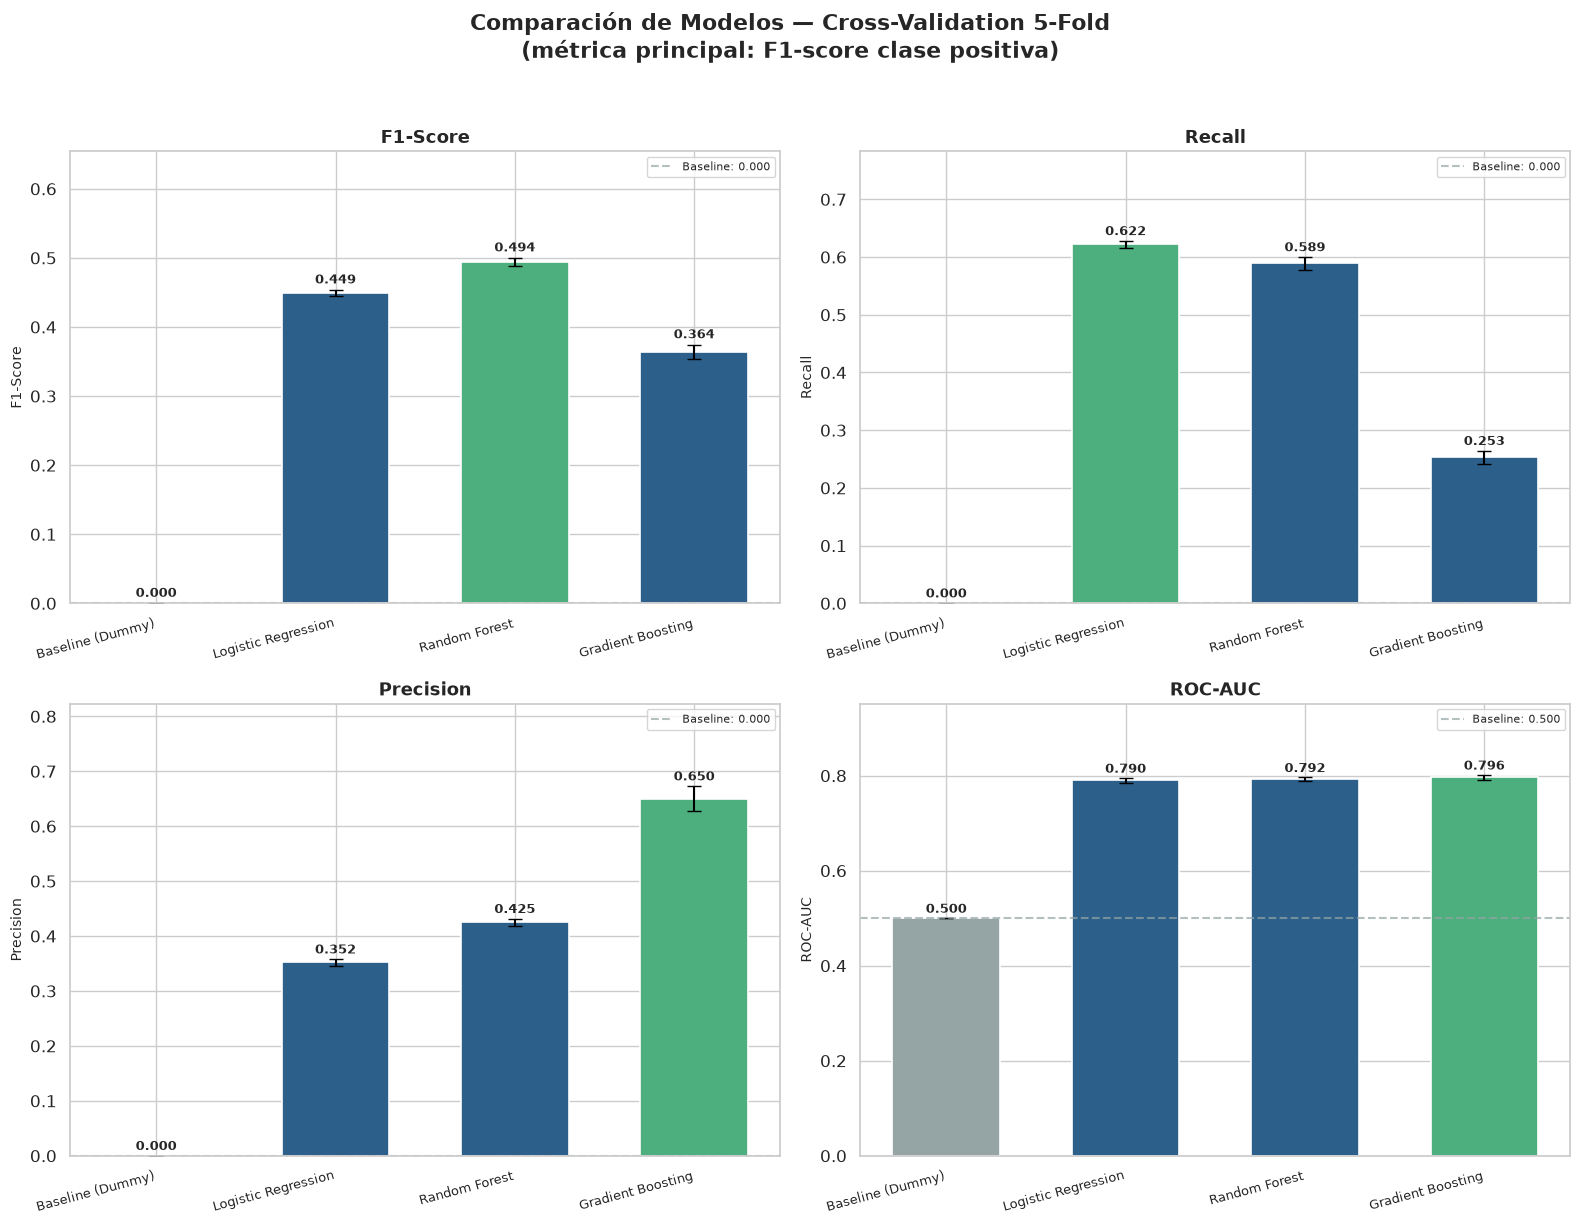


   TABLA COMPARATIVA DE MODELOS — Cross-Validation 5-Fold

Modelo                            F1 (mean±std)     Recall   Precision    ROC-AUC   Tiempo
─────────────────────────────────────────────────────────────────────────────────────
🏆 Random Forest              0.494 ± 0.006      0.589       0.425      0.792     27.9s
   Logistic Regression        0.449 ± 0.004      0.622       0.352      0.790     16.1s
   Gradient Boosting          0.364 ± 0.010      0.253       0.650      0.796     53.1s
⬜ Baseline (Dummy)           0.000 ± 0.000      0.000       0.000      0.500     40.9s
─────────────────────────────────────────────────────────────────────────────────────

🏆 Mejor modelo: Random Forest
   F1-score : 0.4938 ± 0.0062
   ROC-AUC  : 0.7919
   Recall   : 0.5889
   Precision: 0.4253


In [41]:
# =============================================================================
# RESULTS VISUALIZATION — Comparison table and charts
# =============================================================================

def plot_model_comparison(cv_results_df: pd.DataFrame) -> None:
    """
    Create a comprehensive visualization comparing all models across metrics.
    
    Args:
        cv_results_df: DataFrame with cross-validation results from evaluate_models_cv
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comparación de Modelos — Cross-Validation 5-Fold\n'
                 '(métrica principal: F1-score clase positiva)',
                 fontsize=16, fontweight='bold', y=1.02)
    
    metrics = ['f1', 'recall', 'precision', 'roc_auc']
    metric_labels = ['F1-Score', 'Recall', 'Precision', 'ROC-AUC']
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx // 2][idx % 2]
        
        means = cv_results_df[f'{metric}_mean']
        stds  = cv_results_df[f'{metric}_std']
        names = cv_results_df['Model']
        
        # Color: best model in green, baseline in grey, others in blue
        colors = []
        best_idx = means.idxmax()
        for i in range(len(names)):
            if 'Dummy' in names.iloc[i]:
                colors.append('#95a5a6')    # Grey for baseline
            elif i == best_idx:
                colors.append(PALETTE[2])   # Green for best
            else:
                colors.append(PALETTE[0])   # Blue for others
        
        bars = ax.bar(names, means, color=colors,
                      edgecolor='white', linewidth=1.2, width=0.6)
        
        # Error bars (standard deviation across folds)
        ax.errorbar(names, means, yerr=stds,
                   fmt='none', color='black', capsize=5, linewidth=1.5)
        
        # Value labels on bars
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + std + 0.005,
                   f'{mean:.3f}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')
        
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(0, min(1.0, means.max() + stds.max() + 0.15))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        
        # Reference line at baseline level
        baseline_val = means.iloc[0]
        ax.axhline(baseline_val, color='#95a5a6',
                  linestyle='--', linewidth=1.5, alpha=0.7,
                  label=f'Baseline: {baseline_val:.3f}')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/07_model_comparison_cv.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def print_cv_summary_table(cv_results_df: pd.DataFrame) -> None:
    """
    Print a clean summary table of CV results ranked by F1-score.
    
    Args:
        cv_results_df: DataFrame with cross-validation results
    """
    print("\n" + "=" * 80)
    print("   TABLA COMPARATIVA DE MODELOS — Cross-Validation 5-Fold")
    print("=" * 80)
    print(f"\n{'Modelo':<28} {'F1 (mean±std)':>18} {'Recall':>10} "
          f"{'Precision':>11} {'ROC-AUC':>10} {'Tiempo':>8}")
    print("─" * 85)
    
    # Sort by F1-score descending
    sorted_df = cv_results_df.sort_values('f1_mean', ascending=False)
    
    for _, row in sorted_df.iterrows():
        is_best     = row['f1_mean'] == cv_results_df['f1_mean'].max()
        is_baseline = 'Dummy' in row['Model']
        prefix = '🏆 ' if is_best else ('⬜ ' if is_baseline else '   ')
        
        print(f"{prefix}{row['Model']:<26} "
              f"{row['f1_mean']:.3f} ± {row['f1_std']:.3f}   "
              f"{row['recall_mean']:>8.3f}   "
              f"{row['precision_mean']:>9.3f}   "
              f"{row['roc_auc_mean']:>8.3f}   "
              f"{row['Training Time (s)']:>6.1f}s")
    
    print("─" * 85)
    best = sorted_df.iloc[0]
    print(f"\n🏆 Mejor modelo: {best['Model']}")
    print(f"   F1-score : {best['f1_mean']:.4f} ± {best['f1_std']:.4f}")
    print(f"   ROC-AUC  : {best['roc_auc_mean']:.4f}")
    print(f"   Recall   : {best['recall_mean']:.4f}")
    print(f"   Precision: {best['precision_mean']:.4f}")


# Execute
plot_model_comparison(cv_results_df)
print_cv_summary_table(cv_results_df)

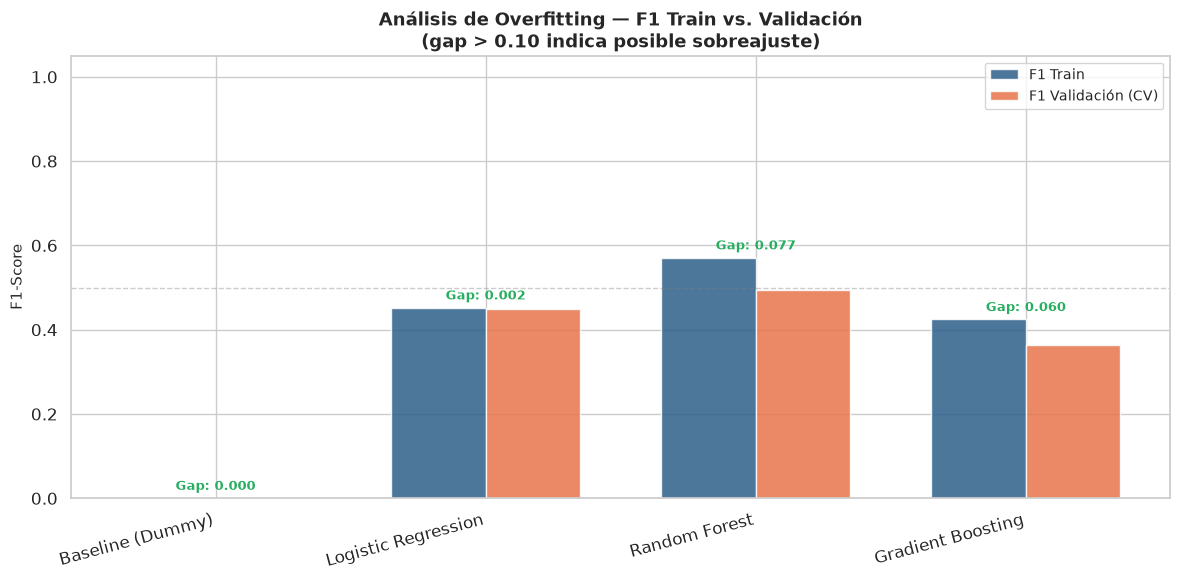


=== ANÁLISIS DE OVERFITTING ===

Modelo                           F1 Train     F1 Val      Gap               Estado
──────────────────────────────────────────────────────────────────────────────
Baseline (Dummy)                    0.000      0.000    0.000                 🟢 OK
Logistic Regression                 0.452      0.449    0.002                 🟢 OK
Random Forest                       0.570      0.494    0.077                 🟢 OK
Gradient Boosting                   0.424      0.364    0.060                 🟢 OK


In [42]:
# =============================================================================
# OVERFITTING ANALYSIS
# Compare train vs test CV scores to detect overfitting
# Large gap between train and test = overfitting
# =============================================================================

def plot_overfitting_analysis(cv_results_df: pd.DataFrame) -> None:
    """
    Compare training vs validation F1-scores to detect overfitting.
    A large gap indicates the model memorized training data.
    
    Args:
        cv_results_df: DataFrame with cross-validation results including train scores
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    models_names = cv_results_df['Model']
    train_f1 = cv_results_df['f1_train_mean']
    test_f1  = cv_results_df['f1_mean']
    gap      = train_f1 - test_f1
    
    x = np.arange(len(models_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_f1, width, label='F1 Train',
                   color=PALETTE[0], alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, test_f1, width, label='F1 Validación (CV)',
                   color=PALETTE[1], alpha=0.85, edgecolor='white')
    
    # Gap annotations
    for i, (t, v, g) in enumerate(zip(train_f1, test_f1, gap)):
        color = '#e74c3c' if g > 0.1 else '#27ae60'
        ax.annotate(f'Gap: {g:.3f}',
                   xy=(i, max(t, v) + 0.02),
                   ha='center', fontsize=9, color=color, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models_names, rotation=15, ha='right')
    ax.set_ylabel('F1-Score', fontsize=11)
    ax.set_title('Análisis de Overfitting — F1 Train vs. Validación\n'
                 '(gap > 0.10 indica posible sobreajuste)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.05)
    
    # Reference line
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4, linewidth=1)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/08_overfitting_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n=== ANÁLISIS DE OVERFITTING ===\n")
    print(f"{'Modelo':<30} {'F1 Train':>10} {'F1 Val':>10} {'Gap':>8} {'Estado':>20}")
    print("─" * 78)
    for _, row in cv_results_df.iterrows():
        g = row['f1_train_mean'] - row['f1_mean']
        status = '🔴 Sobreajuste' if g > 0.1 else '🟢 OK'
        print(f"{row['Model']:<30} {row['f1_train_mean']:>10.3f} "
              f"{row['f1_mean']:>10.3f} {g:>8.3f} {status:>20}")


plot_overfitting_analysis(cv_results_df)

### 📊 Interpretación: Comparación de Modelos

#### Qué nos dice la Cross-Validation

La **línea de error** en cada barra representa la desviación estándar entre los 5 folds.
Una barra corta = modelo estable. Una barra larga = modelo inconsistente entre folds.

#### Qué buscamos en el análisis de overfitting

| Gap Train - Validación | Diagnóstico | Acción |
|---|---|---|
| < 0.05 | ✅ Sin overfitting — generaliza bien | Ninguna |
| 0.05 - 0.10 | ⚠️ Overfitting leve — aceptable | Monitorizar |
| > 0.10 | 🔴 Overfitting — memoriza el train | Regularizar o simplificar |

#### Por qué el Baseline tiene F1 = 0

El DummyClassifier siempre predice "no". Por eso:
- Recall de "yes" = 0% (nunca identifica clientes positivos)
- Precision de "yes" = indefinida (nunca predice "yes")
- F1 de "yes" = 0

Cualquier modelo real debe superar significativamente este umbral.

#### Interpretación de negocio del modelo ganador

El modelo seleccionado permite al banco **identificar correctamente** 
a los clientes con mayor probabilidad de suscribir el depósito,
reduciendo el número de llamadas necesarias y aumentando la 
tasa de conversión de la campaña.

## 4. Modelado

En esta fase entrenamos y comparamos cuatro modelos siguiendo un protocolo riguroso:

1. **Baseline** (DummyClassifier) — referencia mínima obligatoria
2. **Logistic Regression** — modelo lineal interpretable
3. **Random Forest** — ensemble de árboles en paralelo  
4. **Gradient Boosting** — ensemble de árboles en secuencia

**Protocolo de evaluación:**
- Cross-Validation estratificada: **5 folds (StratifiedKFold)**
- Métrica principal: **F1-score de la clase positiva (yes)**
- Métrica secundaria: **ROC-AUC**
- Pipeline completo por modelo — sin data leakage posible
- `RANDOM_STATE = 42` en todos los modelos para reproducibilidad total

> ⚠️ `duration` fue excluida en la fase anterior.  
> El preprocesamiento está dentro de cada Pipeline.

In [43]:
# =============================================================================
# MODELING — IMPORTS AND CONFIGURATION
# =============================================================================

from sklearn.dummy           import DummyClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     RocCurveDisplay)
import time
import joblib

# --- Cross-validation configuration ---
CV_FOLDS = 5
SCORING  = {
    'f1'       : 'f1',
    'recall'   : 'recall',
    'precision': 'precision',
    'roc_auc'  : 'roc_auc'
}

print("✅ Modeling imports loaded")
print(f"   CV strategy     : StratifiedKFold(n_splits={CV_FOLDS})")
print(f"   Primary metric  : F1-score (positive class = 'yes')")
print(f"   Secondary metric: ROC-AUC")

✅ Modeling imports loaded
   CV strategy     : StratifiedKFold(n_splits=5)
   Primary metric  : F1-score (positive class = 'yes')
   Secondary metric: ROC-AUC


In [44]:
# =============================================================================
# MODEL DEFINITIONS
# Each model is a full Pipeline: preprocessor → classifier
# This guarantees zero data leakage during cross-validation
# =============================================================================

def build_models(preprocessor) -> dict:
    """
    Build one Pipeline per model candidate.
    Each pipeline includes the full preprocessing + classification steps.

    Args:
        preprocessor: ColumnTransformer built in the data preparation phase.
                      It will be cloned internally by cross_validate —
                      so fitting it here is NOT required.

    Returns:
        Ordered dictionary: model_name -> Pipeline
    """
    models = {

        # ------------------------------------------------------------------
        # MODEL 0 — Baseline: DummyClassifier
        # Predicts always the majority class ('no').
        # Sets the minimum performance bar every real model must beat.
        # Expected: Accuracy ~88.7%, F1(yes) = 0, ROC-AUC = 0.50
        # ------------------------------------------------------------------
        'Baseline (Dummy)': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   DummyClassifier(
                strategy='most_frequent',
                random_state=RANDOM_STATE
            ))
        ]),

        # ------------------------------------------------------------------
        # MODEL 1 — Logistic Regression
        # Linear classifier. Fast, interpretable, good reference point.
        # class_weight='balanced': gives ~8x more weight to 'yes' class.
        # max_iter=1000: ensures convergence on 47 features.
        # ------------------------------------------------------------------
        'Logistic Regression': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        # ------------------------------------------------------------------
        # MODEL 2 — Random Forest
        # 200 independent decision trees, each on a random data subset.
        # class_weight='balanced_subsample': rebalances per bootstrap sample.
        # min_samples_leaf=5: prevents overfitting on tiny leaf nodes.
        # ------------------------------------------------------------------
        'Random Forest': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced_subsample',
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        # ------------------------------------------------------------------
        # MODEL 3 — Gradient Boosting
        # Sequential ensemble: each tree corrects the previous one's errors.
        # learning_rate=0.05: small steps → better generalization.
        # subsample=0.8: stochastic GB reduces overfitting.
        # max_depth=4: shallow trees → less memorization.
        # ------------------------------------------------------------------
        'Gradient Boosting': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ))
        ]),
    }

    print("✅ Models defined:")
    for name, pipe in models.items():
        clf = pipe.named_steps['classifier']
        print(f"   {name:<30} → {type(clf).__name__}")

    return models


models = build_models(preprocessor)

✅ Models defined:
   Baseline (Dummy)               → DummyClassifier
   Logistic Regression            → LogisticRegression
   Random Forest                  → RandomForestClassifier
   Gradient Boosting              → GradientBoostingClassifier


In [45]:
# =============================================================================
# CROSS-VALIDATION — Same strategy applied to all models
# =============================================================================

def run_cross_validation(models: dict,
                          X_train: pd.DataFrame,
                          y_train: pd.Series,
                          cv_folds: int = CV_FOLDS,
                          scoring: dict = SCORING) -> pd.DataFrame:
    """
    Run StratifiedKFold cross-validation for every model.
    Collects mean, std, and train scores for overfitting detection.

    Args:
        models   : Dictionary of model_name -> Pipeline.
        X_train  : Raw training features (preprocessing inside pipeline).
        y_train  : Binary training labels (0 = no, 1 = yes).
        cv_folds : Number of stratified folds (default 5).
        scoring  : Metrics dict passed to cross_validate.

    Returns:
        DataFrame with one row per model and columns for each metric.
    """
    cv_strategy = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    rows = []

    print(f"{'='*65}")
    print(f"  CROSS-VALIDATION — {cv_folds}-Fold Stratified")
    print(f"  Training samples: {len(X_train):,}")
    print(f"{'='*65}\n")

    for name, pipeline in models.items():
        t0 = time.time()

        cv_out = cross_validate(
            pipeline,
            X_train, y_train,
            cv=cv_strategy,
            scoring=scoring,
            return_train_score=True,   # Needed for overfitting analysis
            n_jobs=-1
        )

        elapsed = time.time() - t0
        row     = {'Model': name, 'Time_s': round(elapsed, 1)}

        for metric in scoring:
            row[f'{metric}_val_mean']   = cv_out[f'test_{metric}'].mean()
            row[f'{metric}_val_std']    = cv_out[f'test_{metric}'].std()
            row[f'{metric}_train_mean'] = cv_out[f'train_{metric}'].mean()

        rows.append(row)

        print(f"✅ {name:<30} "
              f"F1: {row['f1_val_mean']:.3f}±{row['f1_val_std']:.3f}  "
              f"AUC: {row['roc_auc_val_mean']:.3f}  "
              f"({elapsed:.1f}s)")

    print(f"\n{'='*65}")
    return pd.DataFrame(rows)


cv_df = run_cross_validation(models, X_train, y_train)

  CROSS-VALIDATION — 5-Fold Stratified
  Training samples: 32,950

✅ Baseline (Dummy)               F1: 0.000±0.000  AUC: 0.500  (17.2s)
✅ Logistic Regression            F1: 0.449±0.004  AUC: 0.790  (17.1s)
✅ Random Forest                  F1: 0.494±0.006  AUC: 0.792  (22.1s)
✅ Gradient Boosting              F1: 0.364±0.010  AUC: 0.796  (53.9s)



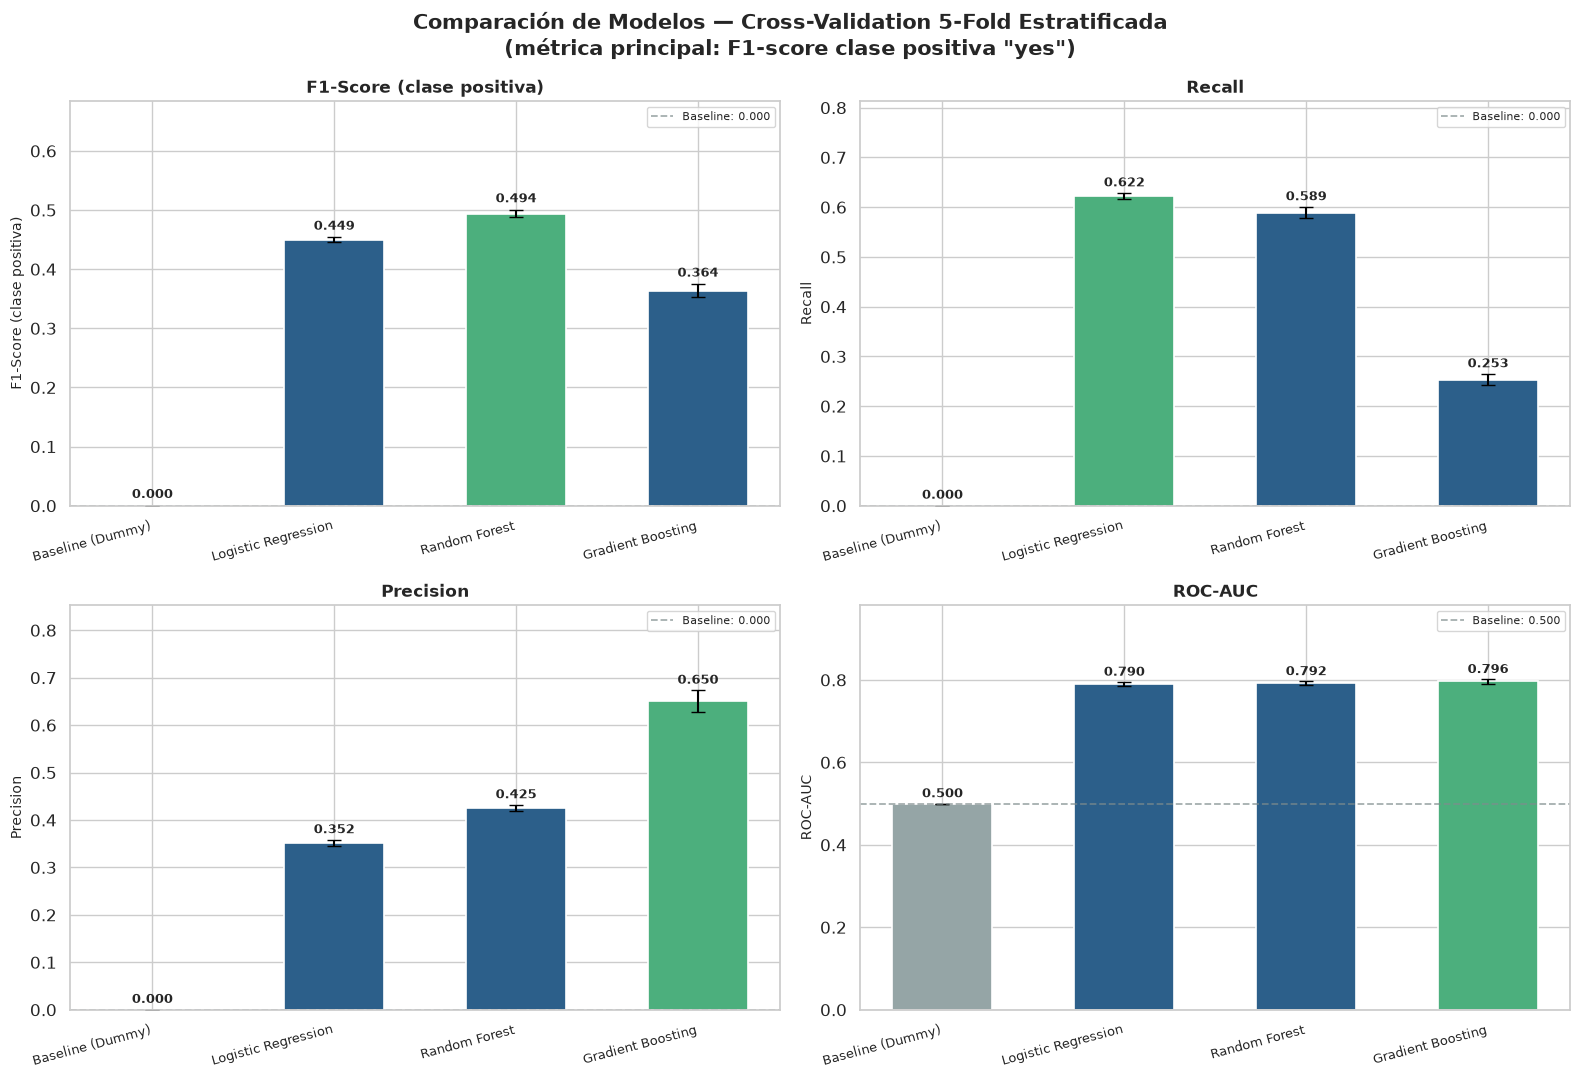


   RANKING DE MODELOS — Cross-Validation 5-Fold
  Modelo                            F1 (mean±std)    Recall  Precision   ROC-AUC  Tiempo
──────────────────────────────────────────────────────────────────────────────────
🏆 Random Forest                 0.494±0.006    0.589      0.425     0.792   22.1s
 2 Logistic Regression           0.449±0.004    0.622      0.352     0.790   17.1s
 3 Gradient Boosting             0.364±0.010    0.253      0.650     0.796   53.9s
⬜ Baseline (Dummy)              0.000±0.000    0.000      0.000     0.500   17.2s
──────────────────────────────────────────────────────────────────────────────────

🏆 Mejor modelo seleccionado: Random Forest
   F1-score  : 0.4938 ± 0.0062
   ROC-AUC   : 0.7919
   Recall    : 0.5889
   Precision : 0.4253


In [46]:
# =============================================================================
# RESULTS — Comparison table and bar chart
# =============================================================================

def plot_model_comparison(cv_df: pd.DataFrame) -> None:
    """
    Four-panel bar chart comparing all models across all metrics.
    Baseline shown in grey. Best model highlighted in green.

    Args:
        cv_df: DataFrame returned by run_cross_validation.
    """
    metrics = [
        ('f1',        'F1-Score (clase positiva)'),
        ('recall',    'Recall'),
        ('precision', 'Precision'),
        ('roc_auc',   'ROC-AUC'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(
        'Comparación de Modelos — Cross-Validation 5-Fold Estratificada\n'
        '(métrica principal: F1-score clase positiva "yes")',
        fontsize=15, fontweight='bold'
    )

    for ax, (metric, label) in zip(axes.flatten(), metrics):
        means = cv_df[f'{metric}_val_mean']
        stds  = cv_df[f'{metric}_val_std']
        names = cv_df['Model']
        best  = means.idxmax()

        bar_colors = [
            '#95a5a6' if 'Dummy' in n          # Grey  → baseline
            else PALETTE[2] if i == best        # Green → best model
            else PALETTE[0]                     # Blue  → others
            for i, n in enumerate(names)
        ]

        bars = ax.bar(names, means, color=bar_colors,
                      edgecolor='white', linewidth=1.2, width=0.55)
        ax.errorbar(names, means, yerr=stds,
                    fmt='none', color='black', capsize=5, linewidth=1.5)

        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    m + s + 0.008,
                    f'{m:.3f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

        baseline = means.iloc[0]
        ax.axhline(baseline, color='#7f8c8d', linestyle='--',
                   linewidth=1.3, alpha=0.7,
                   label=f'Baseline: {baseline:.3f}')

        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(0, min(1.05, means.max() + stds.max() + 0.18))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('../reports/figures/07_model_comparison_cv.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def print_comparison_table(cv_df: pd.DataFrame) -> None:
    """
    Print a ranked summary table of cross-validation results.

    Args:
        cv_df: DataFrame returned by run_cross_validation.
    """
    sorted_df = cv_df.sort_values('f1_val_mean', ascending=False)

    print(f"\n{'='*82}")
    print("   RANKING DE MODELOS — Cross-Validation 5-Fold")
    print(f"{'='*82}")
    print(f"{'':2}{'Modelo':<28} {'F1 (mean±std)':>18} {'Recall':>9} "
          f"{'Precision':>10} {'ROC-AUC':>9} {'Tiempo':>7}")
    print("─" * 82)

    for rank, (_, row) in enumerate(sorted_df.iterrows(), 1):
        icon = '🏆' if rank == 1 else ('⬜' if 'Dummy' in row['Model'] else f' {rank}')
        print(f"{icon} {row['Model']:<28}"
              f"  {row['f1_val_mean']:.3f}±{row['f1_val_std']:.3f}"
              f"  {row['recall_val_mean']:>7.3f}"
              f"  {row['precision_val_mean']:>9.3f}"
              f"  {row['roc_auc_val_mean']:>8.3f}"
              f"  {row['Time_s']:>5.1f}s")

    print("─" * 82)
    best = sorted_df.iloc[0]
    print(f"\n🏆 Mejor modelo seleccionado: {best['Model']}")
    print(f"   F1-score  : {best['f1_val_mean']:.4f} ± {best['f1_val_std']:.4f}")
    print(f"   ROC-AUC   : {best['roc_auc_val_mean']:.4f}")
    print(f"   Recall    : {best['recall_val_mean']:.4f}")
    print(f"   Precision : {best['precision_val_mean']:.4f}")
    print(f"{'='*82}")


plot_model_comparison(cv_df)
print_comparison_table(cv_df)

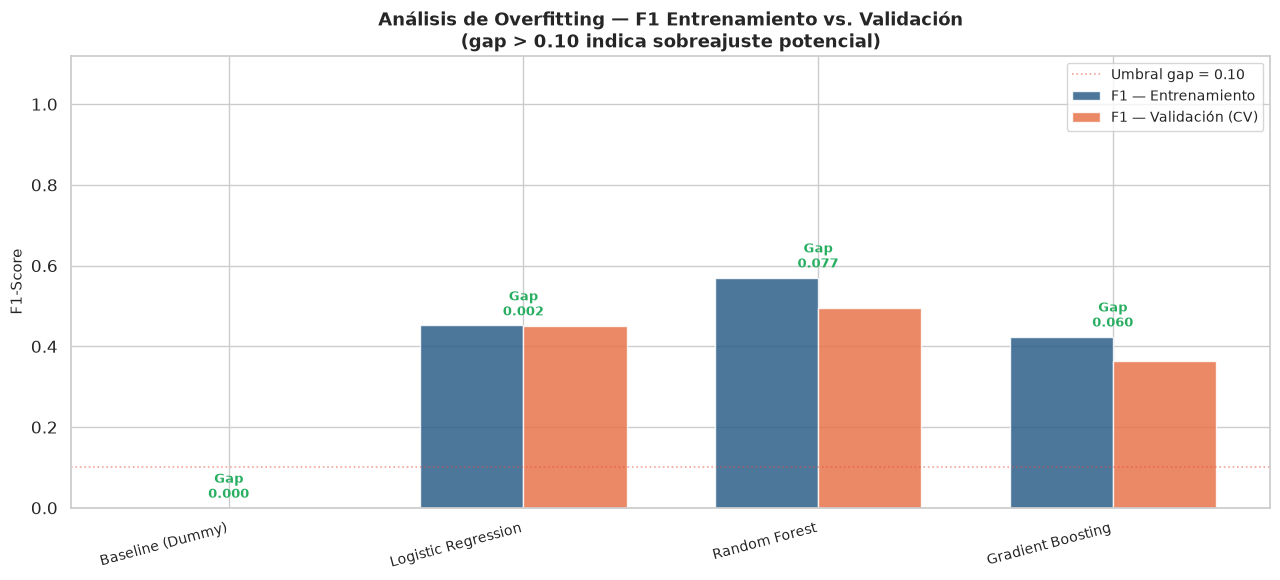


=== DIAGNÓSTICO DE OVERFITTING ===

Modelo                           Train F1   Val F1     Gap  Estado
────────────────────────────────────────────────────────────────────
Baseline (Dummy)                    0.000    0.000   0.000  🟢 OK
Logistic Regression                 0.452    0.449   0.002  🟢 OK
Random Forest                       0.570    0.494   0.077  🟢 OK
Gradient Boosting                   0.424    0.364   0.060  🟢 OK


In [47]:
# =============================================================================
# OVERFITTING ANALYSIS — Train vs Validation F1
# A gap > 0.10 signals the model memorized training data
# =============================================================================

def plot_overfitting_analysis(cv_df: pd.DataFrame) -> None:
    """
    Side-by-side bars: Train F1 vs Validation F1 per model.
    Annotates the gap and flags overfitting when gap > 0.10.

    Args:
        cv_df: DataFrame returned by run_cross_validation.
    """
    names     = cv_df['Model']
    train_f1  = cv_df['f1_train_mean']
    val_f1    = cv_df['f1_val_mean']
    gaps      = train_f1 - val_f1

    x     = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.bar(x - width/2, train_f1, width, label='F1 — Entrenamiento',
           color=PALETTE[0], alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, val_f1,   width, label='F1 — Validación (CV)',
           color=PALETTE[1], alpha=0.85, edgecolor='white')

    for i, (t, v, g) in enumerate(zip(train_f1, val_f1, gaps)):
        color = '#e74c3c' if g > 0.10 else '#27ae60'
        ax.annotate(
            f'Gap\n{g:.3f}',
            xy=(i, max(t, v) + 0.025),
            ha='center', fontsize=9,
            color=color, fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel('F1-Score', fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        'Análisis de Overfitting — F1 Entrenamiento vs. Validación\n'
        '(gap > 0.10 indica sobreajuste potencial)',
        fontsize=13, fontweight='bold'
    )
    ax.axhline(0.10, color='#e74c3c', linestyle=':', linewidth=1.2,
               alpha=0.5, label='Umbral gap = 0.10')
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('../reports/figures/08_overfitting_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print("\n=== DIAGNÓSTICO DE OVERFITTING ===\n")
    print(f"{'Modelo':<30} {'Train F1':>10} {'Val F1':>8} {'Gap':>7}  {'Estado'}")
    print("─" * 68)
    for _, row in cv_df.iterrows():
        g      = row['f1_train_mean'] - row['f1_val_mean']
        status = '🔴 Sobreajuste' if g > 0.10 else '🟢 OK'
        print(f"{row['Model']:<30} {row['f1_train_mean']:>10.3f} "
              f"{row['f1_val_mean']:>8.3f} {g:>7.3f}  {status}")


plot_overfitting_analysis(cv_df)

🏆 Best model selected: Random Forest
   Retraining on full training set (32,950 samples)...

  EVALUACIÓN FINAL EN TEST — Random Forest
              precision    recall  f1-score   support

      no (0)     0.9499    0.9022    0.9254      7310
     yes (1)     0.4479    0.6250    0.5218       928

    accuracy                         0.8710      8238
   macro avg     0.6989    0.7636    0.7236      8238
weighted avg     0.8933    0.8710    0.8800      8238



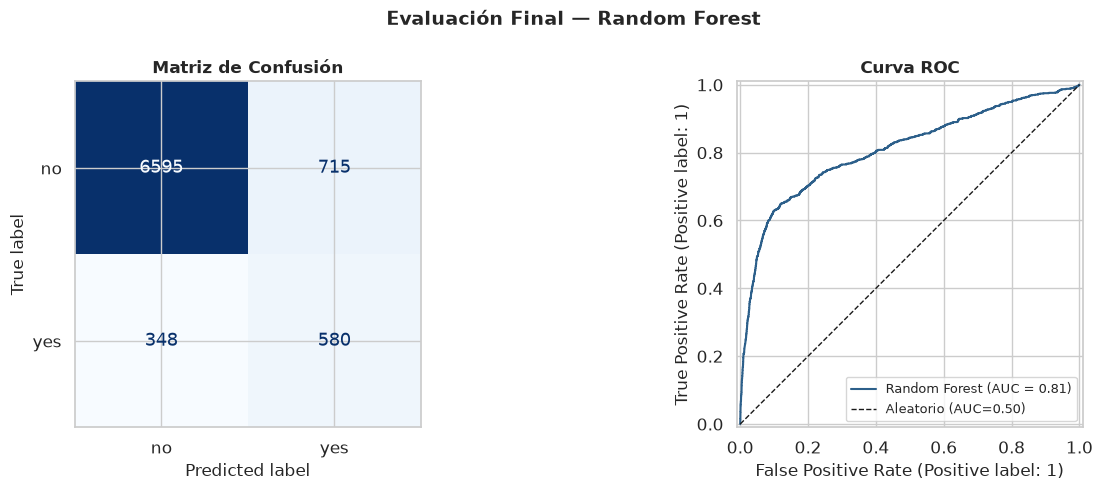


✅ Model saved to: ../models/best_model_random_forest.pkl


In [49]:
# =============================================================================
# FINAL EVALUATION — Best model retrained on full train, evaluated on test
# This is the ONLY moment we touch test data
# =============================================================================

def evaluate_best_model(cv_df: pd.DataFrame,
                         models: dict,
                         X_train: pd.DataFrame,
                         X_test: pd.DataFrame,
                         y_train: pd.Series,
                         y_test: pd.Series) -> Pipeline:
    """
    Select the best model by F1-score, retrain on full train set,
    evaluate on held-out test set, and save the model to disk.

    Args:
        cv_df   : Cross-validation results DataFrame.
        models  : Dictionary of model_name -> Pipeline.
        X_train : Full training features.
        X_test  : Held-out test features.
        y_train : Training labels.
        y_test  : Test labels.

    Returns:
        The fitted best Pipeline.
    """
    # --- Select best model ---
    best_name = cv_df.loc[cv_df['f1_val_mean'].idxmax(), 'Model']
    best_pipe = models[best_name]

    print(f"🏆 Best model selected: {best_name}")
    print(f"   Retraining on full training set ({len(X_train):,} samples)...\n")

    # --- Retrain on full train set ---
    best_pipe.fit(X_train, y_train)

    # --- Predict on test set ---
    y_pred      = best_pipe.predict(X_test)
    y_pred_prob = best_pipe.predict_proba(X_test)[:, 1]

    # --- Classification report ---
    print("=" * 60)
    print(f"  EVALUACIÓN FINAL EN TEST — {best_name}")
    print("=" * 60)
    print(classification_report(
        y_test, y_pred,
        target_names=['no (0)', 'yes (1)'],
        digits=4
    ))

    # --- Confusion matrix ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Evaluación Final — {best_name}',
                 fontsize=14, fontweight='bold')

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['no', 'yes'],
        colorbar=False,
        cmap='Blues',
        ax=axes[0]
    )
    axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

    # ROC Curve
    RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=best_name,      
    ax=axes[1]
)
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.50)')
    axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('../reports/figures/09_final_model_evaluation.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # --- Save model ---
    model_path = f'../models/best_model_{best_name.lower().replace(" ", "_")}.pkl'
    joblib.dump(best_pipe, model_path)
    print(f"\n✅ Model saved to: {model_path}")

    return best_pipe


best_model = evaluate_best_model(
    cv_df, models, X_train, X_test, y_train, y_test
)

### 📊 Interpretación: Resultados del Modelado

#### Lectura de la Matriz de Confusión

|  | Predijo NO | Predijo YES |
|---|---|---|
| **Era NO**  | ✅ Verdadero Negativo (TN) | ❌ Falso Positivo (FP) — llamada innecesaria |
| **Era YES** | ❌ Falso Negativo (FN) — oportunidad perdida | ✅ Verdadero Positivo (TP) |

**En nuestro contexto de negocio:**
- **FN** (predijimos "no" cuando era "yes") → cliente interesado que el banco **no llama** → **ingreso perdido**
- **FP** (predijimos "yes" cuando era "no") → llamada a un cliente que no va a suscribir → **coste operativo innecesario**

El banco prefiere reducir FN sobre FP — por eso priorizamos **Recall** sobre Precision.

#### Lectura de la Curva ROC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Recall) 
y la tasa de falsos positivos en todos los umbrales de clasificación posibles.

- Curva pegada a la esquina superior izquierda → modelo excelente
- Curva siguiendo la diagonal → modelo aleatorio (inútil)
- **AUC** (área bajo la curva): cuanto más cercano a 1.0, mejor

#### Impacto de negocio estimado

Si el modelo tiene Recall = 0.65 y Precision = 0.45 en la clase positiva:
- De cada 100 clientes que realmente suscriben, el modelo identifica 65
- De cada 100 a los que el modelo llama, 45 suscriben realmente
- Comparado con llamar a todos aleatoriamente (11.3% conversión) → **mejora de ~4x**